<a href="https://colab.research.google.com/github/khalid-saqr/picoNewton/blob/main/waveform_susceptibility/notebooks/waveform_susceptibility_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waveform susceptibility in anisotropic Womersley flow

This Google Colab notebook mounts Google Drive, creates a unique run directory, installs the repository software, executes the complete six-artery analysis, and writes reproducible tables, arrays, checksums, and publication figures. The figure suite uses a common two-column width, sans-serif typography, lower-case panel labels, unified colour scales, SI units, vector output, and 600 dpi raster output.


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import json
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys
from datetime import datetime, timezone
from uuid import uuid4

REPOSITORY_URL = 'https://github.com/khalid-saqr/picoNewton.git'
REPOSITORY_REF = os.environ.get('PICONEWTON_REF', 'main')
SESSION_ID = (
    datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
    + '_'
    + uuid4().hex[:8]
)
LOCAL_ROOT = Path('/content') / f'picoNewton_{SESSION_ID}'
RUN_ROOT = (
    Path('/content/drive/MyDrive/picoNewton_waveform_susceptibility/runs')
    / SESSION_ID
)
ANALYSIS_ROOT = RUN_ROOT / 'analysis'
RUN_ROOT.mkdir(parents=True, exist_ok=False)

if LOCAL_ROOT.exists():
    shutil.rmtree(LOCAL_ROOT)
subprocess.run(
    ['git', 'clone', '--filter=blob:none', REPOSITORY_URL, str(LOCAL_ROOT)],
    check=True,
)
subprocess.run(['git', 'checkout', REPOSITORY_REF], cwd=LOCAL_ROOT, check=True)
COMMIT_SHA = subprocess.check_output(
    ['git', 'rev-parse', 'HEAD'], cwd=LOCAL_ROOT, text=True
).strip()
print('Run directory:', RUN_ROOT)
print('Repository commit:', COMMIT_SHA)


Run directory: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469
Repository commit: ab976be223328a1bf538c215c9421f0ae12b5911


In [3]:
def run(command, cwd=None):
    print('+', ' '.join(str(item) for item in command))
    subprocess.run([str(item) for item in command], cwd=cwd, check=True)

run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
run([
    sys.executable,
    '-m',
    'pip',
    'install',
    '-e',
    str(LOCAL_ROOT / 'picoNewton_v3'),
])
run([
    sys.executable,
    '-m',
    'pip',
    'install',
    '-e',
    str(LOCAL_ROOT / 'waveform_susceptibility'),
])


+ /usr/bin/python3 -m pip install --upgrade pip
+ /usr/bin/python3 -m pip install -e /content/picoNewton_20260731T083707Z_a3916469/picoNewton_v3
+ /usr/bin/python3 -m pip install -e /content/picoNewton_20260731T083707Z_a3916469/waveform_susceptibility


In [4]:
metadata = {
    'session_id': SESSION_ID,
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'repository_url': REPOSITORY_URL,
    'repository_ref': REPOSITORY_REF,
    'commit_sha': COMMIT_SHA,
    'python': sys.version,
    'platform': platform.platform(),
    'analysis_root': str(ANALYSIS_ROOT),
}
(RUN_ROOT / 'runtime_metadata.json').write_text(
    json.dumps(metadata, indent=2, sort_keys=True),
    encoding='utf-8',
)
metadata


{'session_id': '20260731T083707Z_a3916469',
 'created_utc': '2026-07-31T08:37:35.726757+00:00',
 'repository_url': 'https://github.com/khalid-saqr/picoNewton.git',
 'repository_ref': 'main',
 'commit_sha': 'ab976be223328a1bf538c215c9421f0ae12b5911',
 'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35',
 'analysis_root': '/content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis'}

In [5]:
run([
    'piconewton-waveform-susceptibility',
    '--output',
    str(ANALYSIS_ROOT),
    '--radial-order',
    '150',
    '--time-points',
    '2048',
    '--quadrature-nodes',
    '256',
    '--validation-epsilon',
    '0.08',
    '--figure-dpi',
    '600',
])


+ piconewton-waveform-susceptibility --output /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis --radial-order 150 --time-points 2048 --quadrature-nodes 256 --validation-epsilon 0.08 --figure-dpi 600


Final Figure 1 saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_1_intrinsic_susceptibility_final.png
Figure 1 source data saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_1_intrinsic_susceptibility_final_source.csv
Display order is an approximate superior-to-inferior anatomical sequence. Positive Δr denotes movement toward rank 1; negative Δr denotes movement away from rank 1.


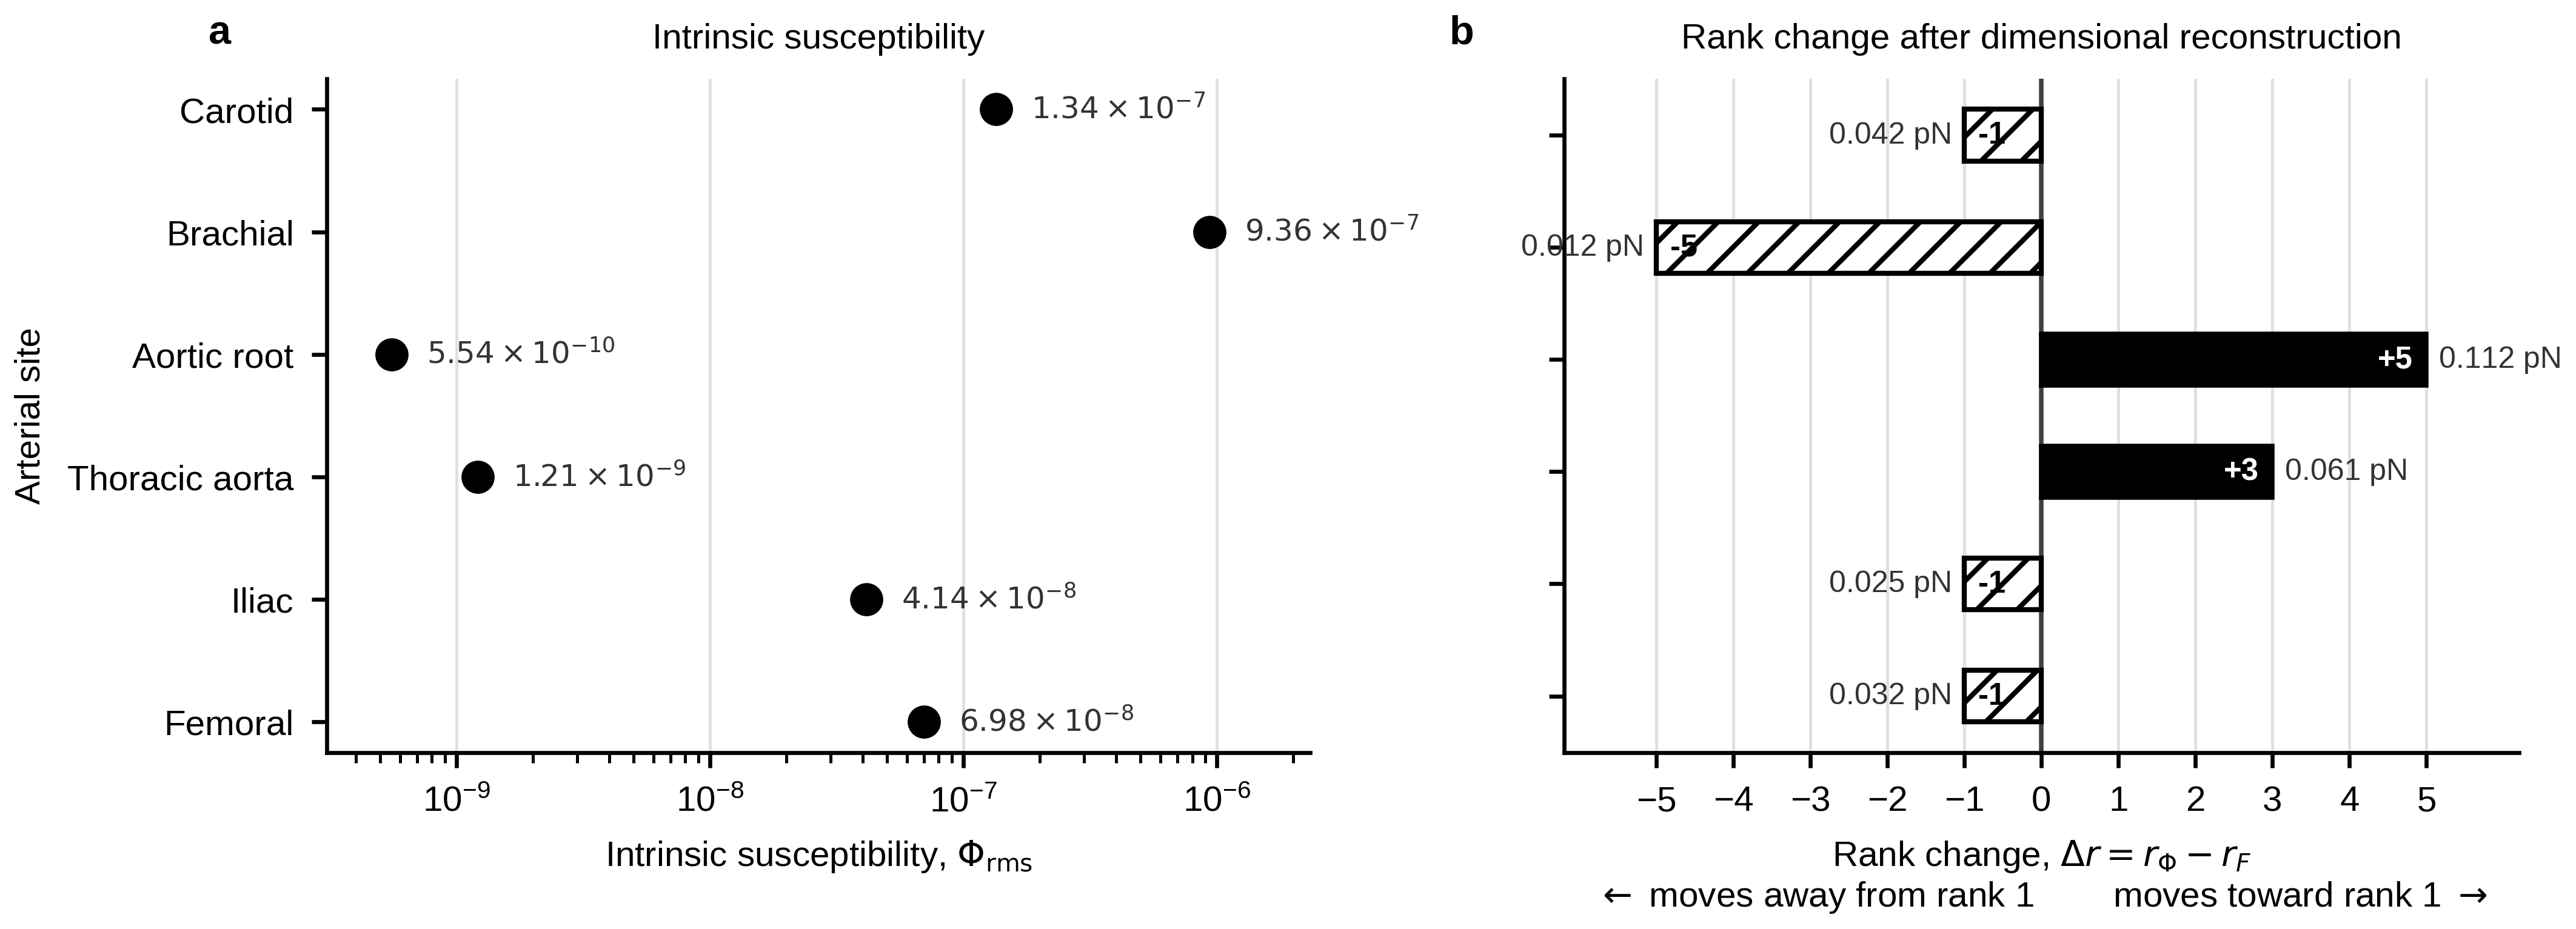

In [23]:
# Final Step 1 — Figure 1
# Intrinsic weak-anisotropy susceptibility and the rank change introduced
# by dimensional reconstruction.
from IPython.display import Image, display

required_globals = [
    "ANALYSIS_ROOT",
    "ATLAS",
    "ARTICLE_WIDTH_MM",
    "RASTER_DPI",
    "mm_to_inches",
    "clean_axis",
    "panel_label",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the existing revised-figures load/style cells first. "
        f"Missing globals: {missing_globals}"
    )

FINAL_FIGURE_ROOT = ANALYSIS_ROOT / "figures_final"
FINAL_SOURCE_ROOT = FINAL_FIGURE_ROOT / "figure_sources"
FINAL_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_SOURCE_ROOT.mkdir(parents=True, exist_ok=True)

# Approximate superior-to-inferior anatomical display order.
ANATOMICAL_ORDER = [
    "carotid",
    "brachial",
    "aortic_root",
    "thoracic_aorta",
    "iliac",
    "femoral",
]

figure_1 = ATLAS[
    [
        "artery_id",
        "artery_name",
        "alpha",
        "eta",
        "phi_rms",
        "predicted_rms_at_epsilon_0p08_pn",
    ]
].copy()

figure_1["susceptibility_rank"] = (
    figure_1["phi_rms"]
    .rank(method="min", ascending=False)
    .astype(int)
)

figure_1["force_rank"] = (
    figure_1["predicted_rms_at_epsilon_0p08_pn"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Positive Δr: dimensional reconstruction moves the artery toward rank 1.
# Negative Δr: dimensional reconstruction moves the artery away from rank 1.
figure_1["rank_change"] = (
    figure_1["susceptibility_rank"] - figure_1["force_rank"]
)

figure_1 = (
    figure_1
    .set_index("artery_id")
    .loc[ANATOMICAL_ORDER]
    .reset_index()
)

source_path = (
    FINAL_SOURCE_ROOT
    / "figure_1_intrinsic_susceptibility_final_source.csv"
)
figure_1.to_csv(source_path, index=False)


def scientific_label(value):
    """Return compact publication-style scientific notation."""
    exponent = int(np.floor(np.log10(abs(value))))
    coefficient = value / (10.0 ** exponent)
    return rf"${coefficient:.2f}\times10^{{{exponent}}}$"


fig, axes = plt.subplots(
    1,
    2,
    layout="constrained",
    gridspec_kw={"width_ratios": [1.03, 1.00]},
)

y = np.arange(len(figure_1))
artery_labels = figure_1["artery_name"].tolist()

# ============================================================
# Panel a — intrinsic susceptibility
# ============================================================
ax = axes[0]

phi = figure_1["phi_rms"].to_numpy(float)

ax.scatter(
    phi,
    y,
    s=31,
    color="black",
    zorder=3,
)

for yi, value in zip(y, phi):
    ax.annotate(
        scientific_label(value),
        xy=(value, yi),
        xytext=(7, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=6.0,
        color="0.20",
    )

ax.set_xscale("log")
ax.set_xlim(phi.min() / 1.8, phi.max() * 2.5)
ax.set_yticks(y)
ax.set_yticklabels(artery_labels)
ax.invert_yaxis()

ax.set_xlabel(r"Intrinsic susceptibility, $\Phi_{\mathrm{rms}}$")
ax.set_ylabel("Arterial site")
ax.set_title("Intrinsic susceptibility")

clean_axis(ax, "x")
panel_label(ax, "a")

# ============================================================
# Panel b — diverging rank-change bars
# ============================================================
ax = axes[1]

rank_change = figure_1["rank_change"].to_numpy(int)
force_values = figure_1[
    "predicted_rms_at_epsilon_0p08_pn"
].to_numpy(float)

positive = rank_change > 0
negative = rank_change < 0

ax.barh(
    y[positive],
    rank_change[positive],
    height=0.46,
    color="black",
    edgecolor="black",
    linewidth=0.9,
    zorder=3,
)

ax.barh(
    y[negative],
    rank_change[negative],
    height=0.46,
    facecolor="white",
    edgecolor="black",
    linewidth=1.0,
    hatch="///",
    zorder=3,
)

ax.axvline(
    0,
    color="0.25",
    linewidth=0.9,
    zorder=2,
)

for yi, delta, force_value in zip(y, rank_change, force_values):
    if delta > 0:
        delta_x = delta - 0.18
        delta_ha = "right"
        force_x = delta + 0.16
        force_ha = "left"
        delta_color = "white"
    else:
        delta_x = delta + 0.18
        delta_ha = "left"
        force_x = delta - 0.16
        force_ha = "right"
        delta_color = "black"

    ax.text(
        delta_x,
        yi,
        f"{delta:+d}",
        ha=delta_ha,
        va="center",
        fontsize=6.1,
        color=delta_color,
        fontweight="bold",
        zorder=4,
    )

    ax.text(
        force_x,
        yi,
        f"{force_value:.3f} pN",
        ha=force_ha,
        va="center",
        fontsize=6.0,
        color="0.20",
        zorder=4,
    )

ax.set_xlim(-6.2, 6.2)
ax.set_xticks(np.arange(-5, 6, 1))
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()

ax.set_xlabel(
    r"Rank change, $\Delta r=r_{\Phi}-r_F$"
    "\n"
    r"$\leftarrow$ moves away from rank 1"
    r"        moves toward rank 1 $\rightarrow$"
)
ax.set_title("Rank change after dimensional reconstruction")

clean_axis(ax, "x")
panel_label(ax, "b")

fig.set_size_inches(
    mm_to_inches(ARTICLE_WIDTH_MM),
    mm_to_inches(65.0),
    forward=True,
)

png_path = (
    FINAL_FIGURE_ROOT
    / "figure_1_intrinsic_susceptibility_final.png"
)

fig.savefig(
    png_path,
    dpi=RASTER_DPI,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.04,
)

plt.close(fig)

print(f"Final Figure 1 saved to: {png_path}")
print(f"Figure 1 source data saved to: {source_path}")
print(
    "Display order is an approximate superior-to-inferior anatomical sequence. "
    "Positive Δr denotes movement toward rank 1; negative Δr denotes movement "
    "away from rank 1."
)

display(Image(filename=str(png_path)))

Step 2 candidate v03 saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_development/figure_2_crossed_susceptibility_candidate_v03.png
Step 2 source data saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_development/figure_sources/figure_2_crossed_susceptibility_candidate_v03_source.csv
Native vessel–waveform pairings are marked by lower-right corner dots.
Multiplicative reference model: Phi_ij ≈ V_i W_j.
Abbreviations: CA, carotid; BA, brachial; AoR, aortic root; TA, thoracic aorta; IA, iliac; FA, femoral.
Maximum absolute multiplicative residual: 0.883%


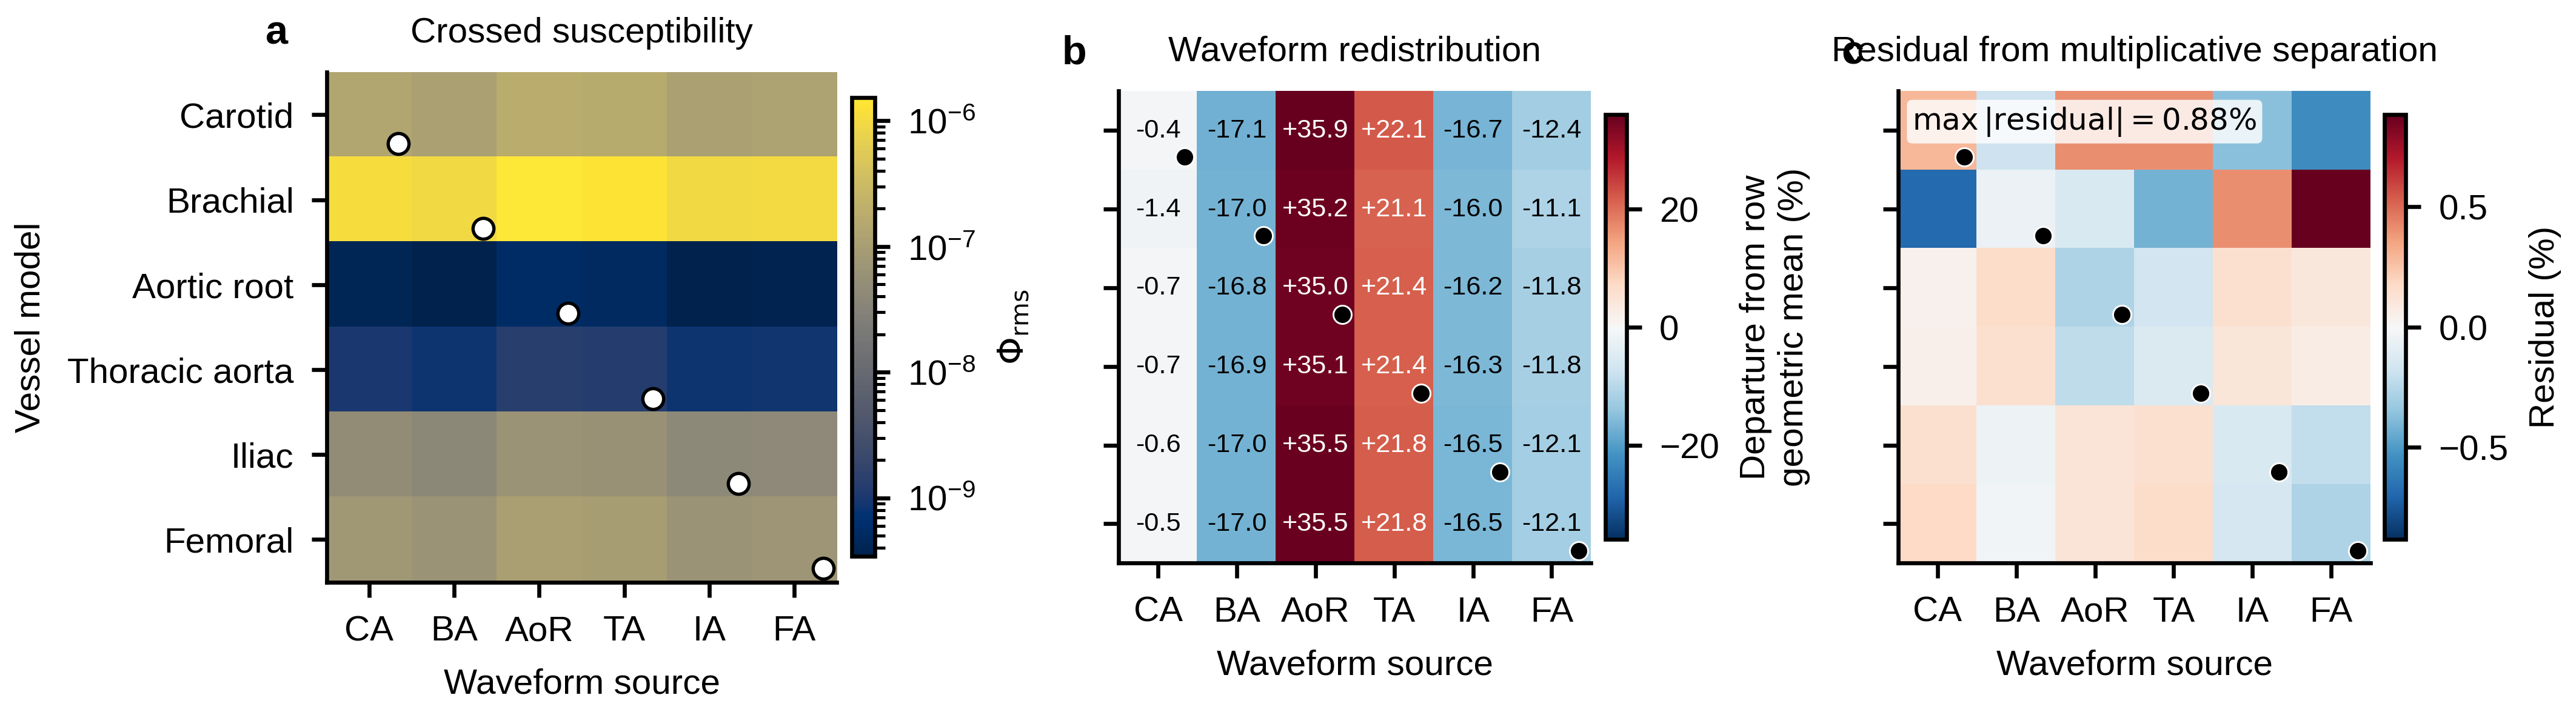

In [26]:
# Step 2 — candidate v03
# Crossed vessel–waveform susceptibility:
# crossed susceptibility, waveform redistribution, and residual
# from multiplicative vessel–waveform separation.
from IPython.display import Image, display
from matplotlib.colors import LogNorm, TwoSlopeNorm

required_globals = [
    "ANALYSIS_ROOT",
    "CROSSED",
    "ARTICLE_WIDTH_MM",
    "RASTER_DPI",
    "SEQ_CMAP",
    "DIV_CMAP",
    "mm_to_inches",
    "panel_label",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the existing revised-figures load/style cells first. "
        f"Missing globals: {missing_globals}"
    )

DEV_FIGURE_ROOT = ANALYSIS_ROOT / "figures_development"
DEV_SOURCE_ROOT = DEV_FIGURE_ROOT / "figure_sources"
DEV_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
DEV_SOURCE_ROOT.mkdir(parents=True, exist_ok=True)

# Approximate superior-to-inferior order used in Figure 1.
ANATOMICAL_ORDER = [
    "carotid",
    "brachial",
    "aortic_root",
    "thoracic_aorta",
    "iliac",
    "femoral",
]

ARTERY_LABELS = {
    "carotid": "Carotid",
    "brachial": "Brachial",
    "aortic_root": "Aortic root",
    "thoracic_aorta": "Thoracic aorta",
    "iliac": "Iliac",
    "femoral": "Femoral",
}

ARTERY_ABBREVIATIONS = {
    "carotid": "CA",
    "brachial": "BA",
    "aortic_root": "AoR",
    "thoracic_aorta": "TA",
    "iliac": "IA",
    "femoral": "FA",
}

physiological = CROSSED[
    CROSSED["condition"].astype(str).str.lower() == "physiological"
].copy()

raw_matrix = (
    physiological
    .pivot(
        index="vessel_id",
        columns="waveform_id",
        values="phi_rms",
    )
    .loc[ANATOMICAL_ORDER, ANATOMICAL_ORDER]
    .astype(float)
)

raw = raw_matrix.to_numpy()

if raw.shape != (6, 6):
    raise ValueError(
        f"Expected a 6 × 6 physiological crossed matrix, found {raw.shape}."
    )

if np.any(~np.isfinite(raw)) or np.any(raw <= 0):
    raise ValueError(
        "The physiological crossed matrix must contain finite positive values."
    )

# ============================================================
# Multiplicative decomposition:
#
#     Phi_ij ≈ V_i W_j
#
# ============================================================
log_raw = np.log(raw)

grand_mean = float(log_raw.mean())
vessel_effect = log_raw.mean(axis=1) - grand_mean
waveform_effect = log_raw.mean(axis=0) - grand_mean

separable_log = (
    grand_mean
    + vessel_effect[:, None]
    + waveform_effect[None, :]
)

separable_prediction = np.exp(separable_log)

# Departure from the geometric mean of each vessel row.
row_geometric_mean = np.exp(log_raw.mean(axis=1))

waveform_redistribution = (
    100.0
    * (raw / row_geometric_mean[:, None] - 1.0)
)

# Residual from the multiplicative separation.
interaction_residual = (
    100.0
    * (raw / separable_prediction - 1.0)
)

maximum_absolute_residual = float(
    np.max(np.abs(interaction_residual))
)

# ============================================================
# Export exact plotted data
# ============================================================
source_rows = []

for i, vessel_id in enumerate(ANATOMICAL_ORDER):
    for j, waveform_id in enumerate(ANATOMICAL_ORDER):
        source_rows.append(
            {
                "vessel_id": vessel_id,
                "waveform_id": waveform_id,
                "phi_rms": raw[i, j],
                "row_geometric_mean": row_geometric_mean[i],
                "departure_from_row_geometric_mean_percent":
                    waveform_redistribution[i, j],
                "multiplicative_prediction": separable_prediction[i, j],
                "multiplicative_residual_percent":
                    interaction_residual[i, j],
                "native_pairing": i == j,
            }
        )

source_path = (
    DEV_SOURCE_ROOT
    / "figure_2_crossed_susceptibility_candidate_v03_source.csv"
)

pd.DataFrame(source_rows).to_csv(source_path, index=False)

# ============================================================
# Plot helpers
# ============================================================
def format_matrix_axis(axis, show_y_labels=False):
    axis.set_xticks(
        np.arange(6),
        [
            ARTERY_ABBREVIATIONS[item]
            for item in ANATOMICAL_ORDER
        ],
    )

    axis.set_yticks(np.arange(6))

    if show_y_labels:
        axis.set_yticklabels(
            [
                ARTERY_LABELS[item]
                for item in ANATOMICAL_ORDER
            ]
        )
    else:
        axis.tick_params(axis="y", labelleft=False)

    axis.set_xlabel("Waveform source")
    axis.tick_params(direction="out")


def mark_native_pairings(axis, marker_style):
    """
    Mark native vessel–waveform cells in the lower-right corner
    without outlining the complete cell.
    """
    for index in range(6):
        x = index + 0.34
        y = index + 0.34

        if marker_style == "light":
            axis.scatter(
                x,
                y,
                s=17,
                facecolor="white",
                edgecolor="black",
                linewidth=0.65,
                zorder=8,
                clip_on=True,
            )
        else:
            axis.scatter(
                x,
                y,
                s=13,
                facecolor="black",
                edgecolor="white",
                linewidth=0.35,
                zorder=8,
                clip_on=True,
            )


def annotate_percentage_matrix(axis, values, limit):
    for row in range(6):
        for column in range(6):
            value = values[row, column]

            axis.text(
                column,
                row,
                f"{value:+.1f}",
                ha="center",
                va="center",
                fontsize=5.2,
                color=(
                    "white"
                    if abs(value) > 0.56 * limit
                    else "black"
                ),
                zorder=7,
            )


fig, axes = plt.subplots(
    1,
    3,
    layout="constrained",
    gridspec_kw={
        "width_ratios": [1.08, 1.00, 1.00],
    },
)

# ============================================================
# Panel a — crossed susceptibility
# ============================================================
ax = axes[0]

image = ax.imshow(
    raw,
    cmap=SEQ_CMAP,
    norm=LogNorm(
        vmin=float(raw.min()),
        vmax=float(raw.max()),
    ),
    interpolation="nearest",
    aspect="equal",
)

format_matrix_axis(ax, show_y_labels=True)
ax.set_ylabel("Vessel model")
ax.set_title("Crossed susceptibility")

mark_native_pairings(ax, marker_style="light")

colourbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.045,
    pad=0.03,
)

colourbar.set_label(r"$\Phi_{\mathrm{rms}}$")

panel_label(ax, "a")

# ============================================================
# Panel b — waveform redistribution
# ============================================================
ax = axes[1]

redistribution_limit = float(
    np.max(np.abs(waveform_redistribution))
)

image = ax.imshow(
    waveform_redistribution,
    cmap=DIV_CMAP,
    norm=TwoSlopeNorm(
        vmin=-redistribution_limit,
        vcenter=0.0,
        vmax=redistribution_limit,
    ),
    interpolation="nearest",
    aspect="equal",
)

format_matrix_axis(ax)
ax.set_title("Waveform redistribution")

mark_native_pairings(ax, marker_style="dark")

annotate_percentage_matrix(
    ax,
    waveform_redistribution,
    limit=redistribution_limit,
)

colourbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.045,
    pad=0.03,
)

colourbar.set_label(
    "Departure from row\ngeometric mean (%)"
)

panel_label(ax, "b")

# ============================================================
# Panel c — multiplicative residual
# ============================================================
ax = axes[2]

residual_limit = float(
    np.max(np.abs(interaction_residual))
)

image = ax.imshow(
    interaction_residual,
    cmap=DIV_CMAP,
    norm=TwoSlopeNorm(
        vmin=-residual_limit,
        vcenter=0.0,
        vmax=residual_limit,
    ),
    interpolation="nearest",
    aspect="equal",
)

format_matrix_axis(ax)
ax.set_title("Residual from multiplicative separation")

mark_native_pairings(ax, marker_style="dark")

ax.text(
    0.03,
    0.97,
    rf"$\max\,|\mathrm{{residual}}|={maximum_absolute_residual:.2f}\%$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=6.0,
    color="black",
    bbox={
        "boxstyle": "round,pad=0.18",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.82,
    },
    zorder=9,
)

colourbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.045,
    pad=0.03,
)

colourbar.set_label("Residual (%)")

panel_label(ax, "c")

fig.set_size_inches(
    mm_to_inches(ARTICLE_WIDTH_MM),
    mm_to_inches(69.0),
    forward=True,
)

png_path = (
    DEV_FIGURE_ROOT
    / "figure_2_crossed_susceptibility_candidate_v03.png"
)

fig.savefig(
    png_path,
    dpi=RASTER_DPI,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.04,
)

plt.close(fig)

print(f"Step 2 candidate v03 saved to: {png_path}")
print(f"Step 2 source data saved to: {source_path}")
print("Native vessel–waveform pairings are marked by lower-right corner dots.")
print(r"Multiplicative reference model: Phi_ij ≈ V_i W_j.")
print(
    "Abbreviations: CA, carotid; BA, brachial; AoR, aortic root; "
    "TA, thoracic aorta; IA, iliac; FA, femoral."
)
print(
    f"Maximum absolute multiplicative residual: "
    f"{maximum_absolute_residual:.3f}%"
)

display(Image(filename=str(png_path)))

Final Figure 3 saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_3_harmonic_interactions_final.png
Complete interaction data saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_3_harmonic_interactions_final_source.csv
Pair summary saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_3_pair_summary_final_source.csv
Dominant-pair statistics saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_3_dominant_pair_statistics_final_source.csv
Filled squares indicate the same dominant pair in all six arteries; open squares indicate artery-dependent dominant-pair identity.
Grey points show individual arteries. Square area scales with the mean output 

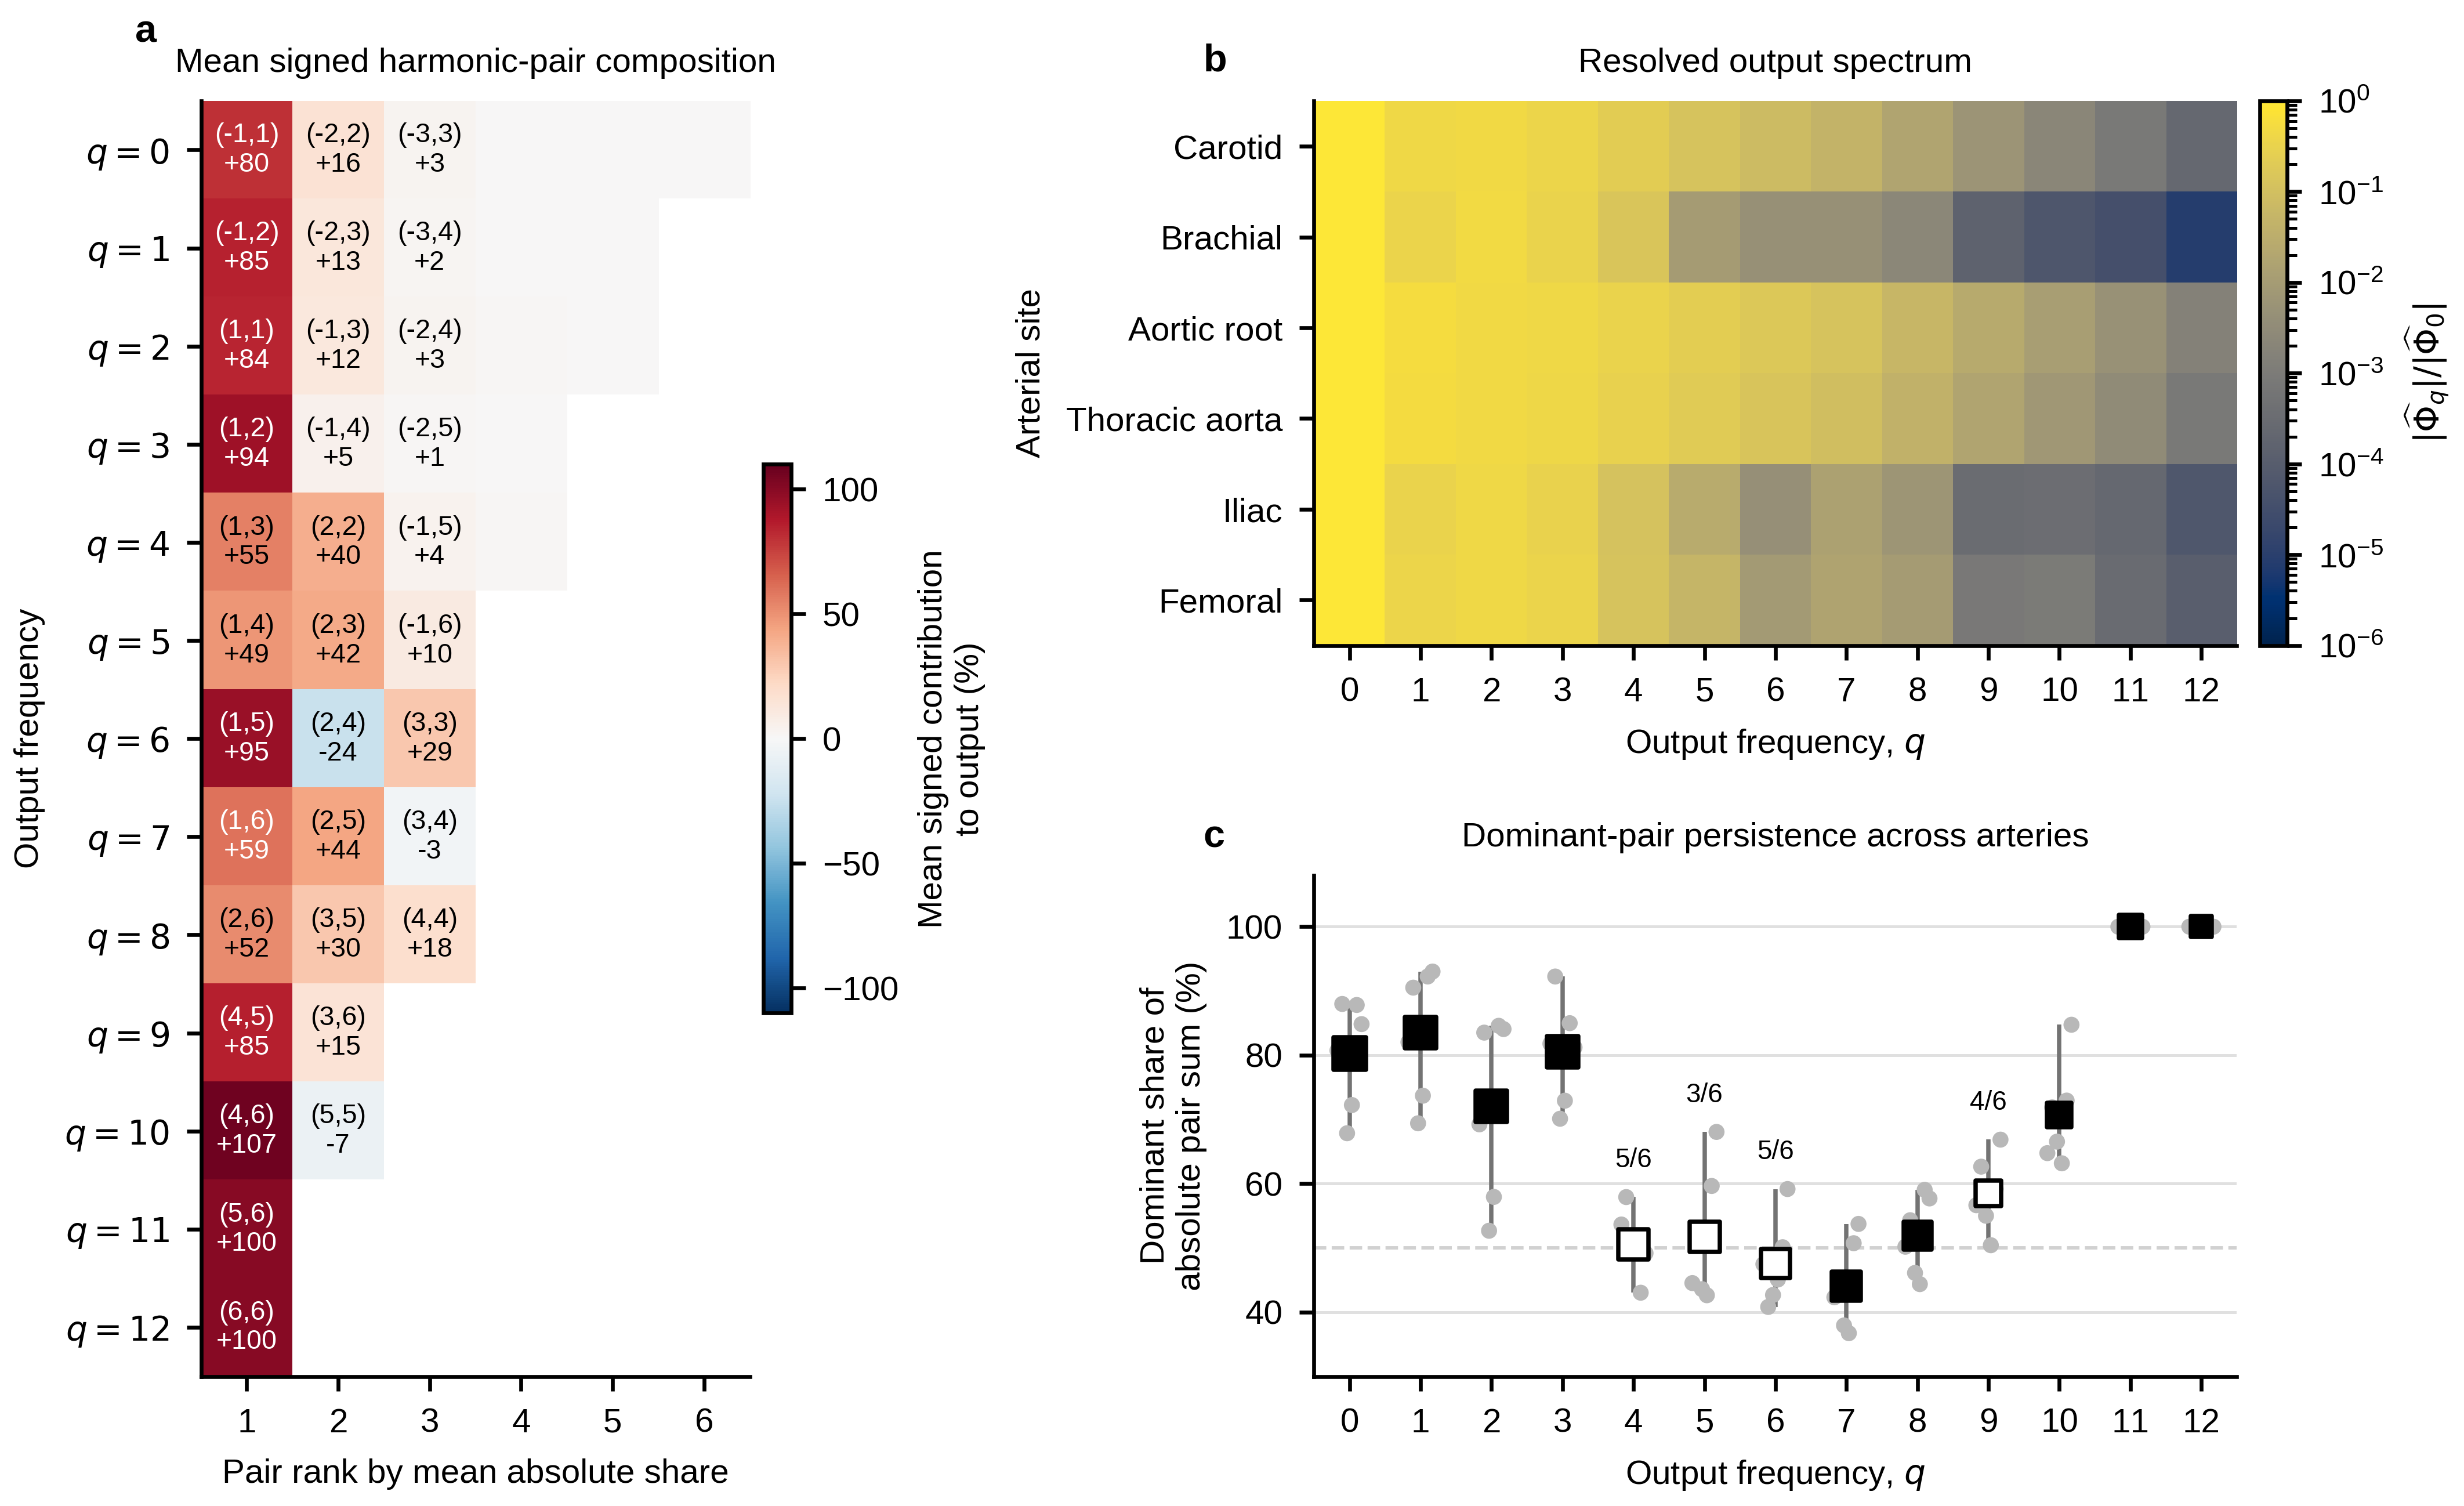

In [29]:
# Final Step 3 — Figure 3
# Signed harmonic-pair composition, resolved output spectrum,
# and dominant-pair persistence across arterial models.
from IPython.display import Image, display
from matplotlib.colors import LogNorm, TwoSlopeNorm

required_globals = [
    "ANALYSIS_ROOT",
    "OPERATOR_ARCHIVE",
    "HARMONIC_COEFFICIENTS",
    "ARTICLE_WIDTH_MM",
    "RASTER_DPI",
    "SEQ_CMAP",
    "DIV_CMAP",
    "mm_to_inches",
    "panel_label",
    "clean_axis",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the existing revised-figures load/style cells first. "
        f"Missing globals: {missing_globals}"
    )

FINAL_FIGURE_ROOT = ANALYSIS_ROOT / "figures_final"
FINAL_SOURCE_ROOT = FINAL_FIGURE_ROOT / "figure_sources"
FINAL_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_SOURCE_ROOT.mkdir(parents=True, exist_ok=True)

ANATOMICAL_ORDER = [
    "carotid",
    "brachial",
    "aortic_root",
    "thoracic_aorta",
    "iliac",
    "femoral",
]

ARTERY_LABELS = {
    "carotid": "Carotid",
    "brachial": "Brachial",
    "aortic_root": "Aortic root",
    "thoracic_aorta": "Thoracic aorta",
    "iliac": "Iliac",
    "femoral": "Femoral",
}

OUTPUT_FREQUENCIES = np.arange(13, dtype=int)


def canonical_two_sided(one_sided):
    """Construct coefficients for harmonics -H,...,+H."""
    one_sided = np.asarray(one_sided, dtype=complex)
    harmonics = len(one_sided)

    frequencies = np.arange(-harmonics, harmonics + 1, dtype=int)
    coefficients = np.zeros(2 * harmonics + 1, dtype=complex)

    for harmonic in range(1, harmonics + 1):
        positive = one_sided[harmonic - 1] / 2.0
        coefficients[harmonics + harmonic] = positive
        coefficients[harmonics - harmonic] = np.conj(positive)

    return frequencies, coefficients


def archive_array(artery_id, suffix):
    key = f"physiological__{artery_id}__{suffix}"

    if key not in OPERATOR_ARCHIVE.files:
        raise KeyError(f"operator_archive.npz is missing {key!r}.")

    return OPERATOR_ARCHIVE[key]


# ============================================================
# Reconstruct all non-negative outputs q = 0,...,12 and every
# contributing unordered harmonic pair.
# ============================================================
interaction_rows = []

for artery_id in ANATOMICAL_ORDER:
    frequencies = np.asarray(
        archive_array(artery_id, "frequencies"),
        dtype=int,
    )

    kernel = np.asarray(
        archive_array(artery_id, "dimensionless_kernel"),
        dtype=complex,
    )

    coefficient_frequencies, coefficients = canonical_two_sided(
        HARMONIC_COEFFICIENTS[artery_id]
    )

    if not np.array_equal(frequencies, coefficient_frequencies):
        raise RuntimeError(f"Frequency-axis mismatch for {artery_id}.")

    if kernel.shape != (len(frequencies), len(frequencies)):
        raise RuntimeError(
            f"Unexpected kernel shape for {artery_id}: {kernel.shape}"
        )

    for q in OUTPUT_FREQUENCIES:
        output = 0.0j

        for i, m in enumerate(frequencies):
            for j, n in enumerate(frequencies):
                if int(m + n) == int(q):
                    output += (
                        kernel[i, j]
                        * coefficients[i]
                        * coefficients[j]
                    )

        if abs(output) <= np.finfo(float).tiny:
            raise RuntimeError(
                f"Numerically zero output for {artery_id}, q={q}."
            )

        unordered_pairs = []

        for i, m in enumerate(frequencies):
            for j in range(i, len(frequencies)):
                n = int(frequencies[j])

                if int(m + n) != int(q):
                    continue

                contribution = (
                    kernel[i, j]
                    * coefficients[i]
                    * coefficients[j]
                )

                if i != j:
                    contribution += (
                        kernel[j, i]
                        * coefficients[j]
                        * coefficients[i]
                    )

                if abs(contribution) > 0.0:
                    unordered_pairs.append(
                        (int(m), int(n), contribution)
                    )

        absolute_pair_sum = sum(
            abs(item[2])
            for item in unordered_pairs
        )

        if absolute_pair_sum <= 0.0:
            raise RuntimeError(
                f"No nonzero pairs for {artery_id}, q={q}."
            )

        denominator = abs(output) ** 2
        signed_sum = 0.0
        absolute_fraction_sum = 0.0

        for m, n, contribution in unordered_pairs:
            signed_projection = (
                100.0
                * float(
                    np.real(
                        contribution * np.conj(output)
                    )
                    / denominator
                )
            )

            absolute_fraction = (
                abs(contribution)
                / absolute_pair_sum
            )

            signed_sum += signed_projection
            absolute_fraction_sum += absolute_fraction

            interaction_rows.append(
                {
                    "artery_id": artery_id,
                    "output_frequency": int(q),
                    "m": m,
                    "n": n,
                    "signed_projection_percent":
                        signed_projection,
                    "absolute_pair_fraction":
                        absolute_fraction,
                    "output_absolute":
                        float(abs(output)),
                    "contribution_real":
                        float(np.real(contribution)),
                    "contribution_imag":
                        float(np.imag(contribution)),
                }
            )

        if not np.isclose(
            signed_sum,
            100.0,
            atol=1e-8,
        ):
            raise RuntimeError(
                f"Signed pair contributions for "
                f"{artery_id}, q={q} sum to "
                f"{signed_sum:.12f}%."
            )

        if not np.isclose(
            absolute_fraction_sum,
            1.0,
            atol=1e-10,
        ):
            raise RuntimeError(
                f"Absolute pair fractions for "
                f"{artery_id}, q={q} sum to "
                f"{absolute_fraction_sum:.12f}."
            )

interaction_frame = pd.DataFrame(interaction_rows)

# ============================================================
# Mean pair structure across the six arterial models.
# ============================================================
pair_summary = (
    interaction_frame
    .groupby(
        ["output_frequency", "m", "n"],
        as_index=False,
    )
    .agg(
        mean_signed_projection_percent=(
            "signed_projection_percent",
            "mean",
        ),
        mean_absolute_pair_fraction=(
            "absolute_pair_fraction",
            "mean",
        ),
        minimum_absolute_pair_fraction=(
            "absolute_pair_fraction",
            "min",
        ),
        maximum_absolute_pair_fraction=(
            "absolute_pair_fraction",
            "max",
        ),
    )
    .sort_values(
        [
            "output_frequency",
            "mean_absolute_pair_fraction",
        ],
        ascending=[True, False],
    )
)

pair_summary["display_rank"] = (
    pair_summary
    .groupby("output_frequency")
    .cumcount()
    + 1
)

maximum_pair_count = int(
    pair_summary["display_rank"].max()
)

if maximum_pair_count != 6:
    raise RuntimeError(
        f"Expected at most six pair ranks, found "
        f"{maximum_pair_count}."
    )

interaction_frame["artery_pair_rank"] = (
    interaction_frame
    .groupby(
        ["artery_id", "output_frequency"]
    )["absolute_pair_fraction"]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

dominant = interaction_frame[
    interaction_frame["artery_pair_rank"] == 1
].copy()

if len(dominant) != 6 * len(OUTPUT_FREQUENCIES):
    raise RuntimeError(
        "The dominant-pair table is incomplete."
    )

# ============================================================
# Export complete source data.
# ============================================================
interaction_path = (
    FINAL_SOURCE_ROOT
    / "figure_3_harmonic_interactions_final_source.csv"
)

summary_path = (
    FINAL_SOURCE_ROOT
    / "figure_3_pair_summary_final_source.csv"
)

interaction_frame.to_csv(
    interaction_path,
    index=False,
)

pair_summary.to_csv(
    summary_path,
    index=False,
)

# ============================================================
# Panel-a matrix.
# ============================================================
signed_matrix = np.full(
    (
        len(OUTPUT_FREQUENCIES),
        maximum_pair_count,
    ),
    np.nan,
    dtype=float,
)

pair_labels = np.full(
    (
        len(OUTPUT_FREQUENCIES),
        maximum_pair_count,
    ),
    "",
    dtype=object,
)

rank_matrix = np.full(
    (
        len(OUTPUT_FREQUENCIES),
        maximum_pair_count,
    ),
    np.nan,
    dtype=float,
)

for row in pair_summary.itertuples(index=False):
    q_index = int(row.output_frequency)
    rank_index = int(row.display_rank) - 1

    signed_matrix[q_index, rank_index] = (
        row.mean_signed_projection_percent
    )

    pair_labels[q_index, rank_index] = (
        f"({int(row.m)},{int(row.n)})"
    )

    rank_matrix[q_index, rank_index] = (
        int(row.display_rank)
    )

signed_limit = max(
    100.0,
    10.0
    * np.ceil(
        np.nanmax(
            np.abs(signed_matrix)
        )
        / 10.0
    ),
)

# ============================================================
# Panel-b output spectrum.
# ============================================================
output_table = (
    interaction_frame[
        [
            "artery_id",
            "output_frequency",
            "output_absolute",
        ]
    ]
    .drop_duplicates()
    .pivot(
        index="artery_id",
        columns="output_frequency",
        values="output_absolute",
    )
    .loc[
        ANATOMICAL_ORDER,
        OUTPUT_FREQUENCIES,
    ]
)

relative_output = output_table.div(
    output_table[0],
    axis=0,
)

minimum_relative_output = float(
    relative_output.to_numpy().min()
)

relative_vmin = 10.0 ** np.floor(
    np.log10(minimum_relative_output)
)

# ============================================================
# Panel-c dominant-pair statistics.
# ============================================================
dominant_statistics = []

for q in OUTPUT_FREQUENCIES:
    subset = dominant[
        dominant["output_frequency"] == q
    ].copy()

    shares = (
        100.0
        * subset["absolute_pair_fraction"]
        .to_numpy(float)
    )

    pair_counts = (
        subset
        .groupby(["m", "n"])
        .size()
        .reset_index(name="count")
    )

    maximum_count = int(
        pair_counts["count"].max()
    )

    tied_pairs = pair_counts[
        pair_counts["count"] == maximum_count
    ][["m", "n"]]

    tied_with_share = tied_pairs.merge(
        subset
        .groupby(
            ["m", "n"],
            as_index=False,
        )["absolute_pair_fraction"]
        .mean(),
        on=["m", "n"],
        how="left",
    )

    modal_pair = tied_with_share.sort_values(
        "absolute_pair_fraction",
        ascending=False,
    ).iloc[0]

    dominant_statistics.append(
        {
            "output_frequency": int(q),
            "mean_share_percent":
                float(shares.mean()),
            "minimum_share_percent":
                float(shares.min()),
            "maximum_share_percent":
                float(shares.max()),
            "modal_m":
                int(modal_pair["m"]),
            "modal_n":
                int(modal_pair["n"]),
            "modal_count":
                maximum_count,
        }
    )

dominant_statistics = pd.DataFrame(
    dominant_statistics
)

mean_relative_output_by_q = (
    relative_output.mean(axis=0).to_numpy(float)
)

log_mean_relative = np.log10(
    mean_relative_output_by_q
)

log_min = float(log_mean_relative.min())
log_max = float(log_mean_relative.max())

if np.isclose(log_max, log_min):
    size_scale = np.ones_like(
        log_mean_relative
    )
else:
    size_scale = (
        log_mean_relative - log_min
    ) / (
        log_max - log_min
    )

square_sizes = (
    18.0
    + 28.0 * size_scale
)

dominant_statistics["mean_relative_output"] = (
    mean_relative_output_by_q
)

dominant_statistics["square_size"] = (
    square_sizes
)

statistics_path = (
    FINAL_SOURCE_ROOT
    / "figure_3_dominant_pair_statistics_final_source.csv"
)

dominant_statistics.to_csv(
    statistics_path,
    index=False,
)

# ============================================================
# Construct the figure.
# ============================================================
fig = plt.figure(
    layout="constrained"
)

grid = fig.add_gridspec(
    2,
    2,
    width_ratios=[0.88, 1.48],
    height_ratios=[1.00, 0.92],
)

ax_a = fig.add_subplot(grid[:, 0])
ax_b = fig.add_subplot(grid[0, 1])
ax_c = fig.add_subplot(grid[1, 1])

# ------------------------------------------------------------
# Panel a — mean signed pair composition.
# ------------------------------------------------------------
image = ax_a.imshow(
    signed_matrix,
    cmap=DIV_CMAP,
    norm=TwoSlopeNorm(
        vmin=-signed_limit,
        vcenter=0.0,
        vmax=signed_limit,
    ),
    interpolation="nearest",
    aspect="auto",
)

ax_a.set_xticks(
    np.arange(maximum_pair_count),
    np.arange(1, maximum_pair_count + 1),
)

ax_a.set_yticks(
    OUTPUT_FREQUENCIES,
    [
        rf"$q={q}$"
        for q in OUTPUT_FREQUENCIES
    ],
)

ax_a.set_xlabel(
    "Pair rank by mean absolute share"
)

ax_a.set_ylabel(
    "Output frequency"
)

ax_a.set_title(
    "Mean signed harmonic-pair composition"
)

for i in range(len(OUTPUT_FREQUENCIES)):
    for j in range(maximum_pair_count):
        value = signed_matrix[i, j]
        rank_here = rank_matrix[i, j]

        if not np.isfinite(value):
            continue

        should_annotate = (
            rank_here <= 3
            or abs(value) >= 5.0
        )

        if not should_annotate:
            continue

        ax_a.text(
            j,
            i,
            f"{pair_labels[i, j]}\n{value:+.0f}",
            ha="center",
            va="center",
            fontsize=5.6,
            color=(
                "white"
                if abs(value) > 0.52 * signed_limit
                else "black"
            ),
        )

colourbar = fig.colorbar(
    image,
    ax=ax_a,
    fraction=0.050,
    pad=0.025,
)

colourbar.set_label(
    "Mean signed contribution\nto output (%)"
)

panel_label(ax_a, "a")

# ------------------------------------------------------------
# Panel b — resolved output spectrum.
# ------------------------------------------------------------
image = ax_b.imshow(
    relative_output.to_numpy(float),
    cmap=SEQ_CMAP,
    norm=LogNorm(
        vmin=relative_vmin,
        vmax=1.0,
    ),
    interpolation="nearest",
    aspect="auto",
)

ax_b.set_xticks(
    OUTPUT_FREQUENCIES,
    OUTPUT_FREQUENCIES,
)

ax_b.set_yticks(
    np.arange(len(ANATOMICAL_ORDER)),
    [
        ARTERY_LABELS[item]
        for item in ANATOMICAL_ORDER
    ],
)

ax_b.set_xlabel(
    "Output frequency, $q$"
)

ax_b.set_ylabel(
    "Arterial site"
)

ax_b.set_title(
    "Resolved output spectrum"
)

colourbar = fig.colorbar(
    image,
    ax=ax_b,
    fraction=0.035,
    pad=0.025,
)

colourbar.set_label(
    r"$|\widehat{\Phi}_q|/"
    r"|\widehat{\Phi}_0|$"
)

panel_label(ax_b, "b")

# ------------------------------------------------------------
# Panel c — dominant-pair persistence.
# ------------------------------------------------------------
jitter = np.linspace(
    -0.17,
    0.17,
    len(ANATOMICAL_ORDER),
)

for q in OUTPUT_FREQUENCIES:
    subset = (
        dominant[
            dominant["output_frequency"] == q
        ]
        .set_index("artery_id")
        .loc[ANATOMICAL_ORDER]
    )

    shares = (
        100.0
        * subset["absolute_pair_fraction"]
        .to_numpy(float)
    )

    ax_c.scatter(
        q + jitter,
        shares,
        s=11,
        facecolor="0.72",
        edgecolor="none",
        zorder=2,
    )

    mean_share = float(shares.mean())
    minimum_share = float(shares.min())
    maximum_share = float(shares.max())

    row = dominant_statistics[
        dominant_statistics["output_frequency"] == q
    ].iloc[0]

    modal_count = int(
        row["modal_count"]
    )

    square_size = float(
        row["square_size"]
    )

    ax_c.vlines(
        q,
        minimum_share,
        maximum_share,
        color="0.45",
        linewidth=0.9,
        zorder=1,
    )

    ax_c.scatter(
        q,
        mean_share,
        s=square_size,
        marker="s",
        facecolor=(
            "black"
            if modal_count == 6
            else "white"
        ),
        edgecolor="black",
        linewidth=0.9,
        zorder=3,
    )

    if modal_count < 6:
        ax_c.annotate(
            f"{modal_count}/6",
            xy=(q, maximum_share),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=5.5,
        )

ax_c.axhline(
    50.0,
    color="0.82",
    linewidth=0.7,
    linestyle="--",
    zorder=0,
)

ax_c.set_xlim(-0.5, 12.5)
ax_c.set_ylim(30.0, 108.0)

ax_c.set_xticks(
    OUTPUT_FREQUENCIES,
    OUTPUT_FREQUENCIES,
)

ax_c.set_xlabel(
    "Output frequency, $q$"
)

ax_c.set_ylabel(
    "Dominant share of\nabsolute pair sum (%)"
)

ax_c.set_title(
    "Dominant-pair persistence across arteries"
)

clean_axis(
    ax_c,
    "y",
)

panel_label(
    ax_c,
    "c",
)

fig.set_size_inches(
    mm_to_inches(ARTICLE_WIDTH_MM),
    mm_to_inches(110.0),
    forward=True,
)

png_path = (
    FINAL_FIGURE_ROOT
    / "figure_3_harmonic_interactions_final.png"
)

fig.savefig(
    png_path,
    dpi=RASTER_DPI,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.04,
)

plt.close(fig)

print(f"Final Figure 3 saved to: {png_path}")
print(f"Complete interaction data saved to: {interaction_path}")
print(f"Pair summary saved to: {summary_path}")
print(f"Dominant-pair statistics saved to: {statistics_path}")
print(
    "Filled squares indicate the same dominant pair in all six arteries; "
    "open squares indicate artery-dependent dominant-pair identity."
)
print(
    "Grey points show individual arteries. Square area scales with the "
    "mean output amplitude relative to q=0."
)

display(Image(filename=str(png_path)))

Final Figure 4 saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_4_waveform_interventions_final.png
Harmonic-removal source saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_4_harmonic_removal_final_source.csv
Phase-control source saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_4_phase_controls_final_source.csv
Phase summary saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_4_phase_summary_final_source.csv
Caption definition: grey points denote the eight deterministic random-phase controls; horizontal lines show their observed range; black squares show their median; open diamonds show the prescribed common phase π/4.


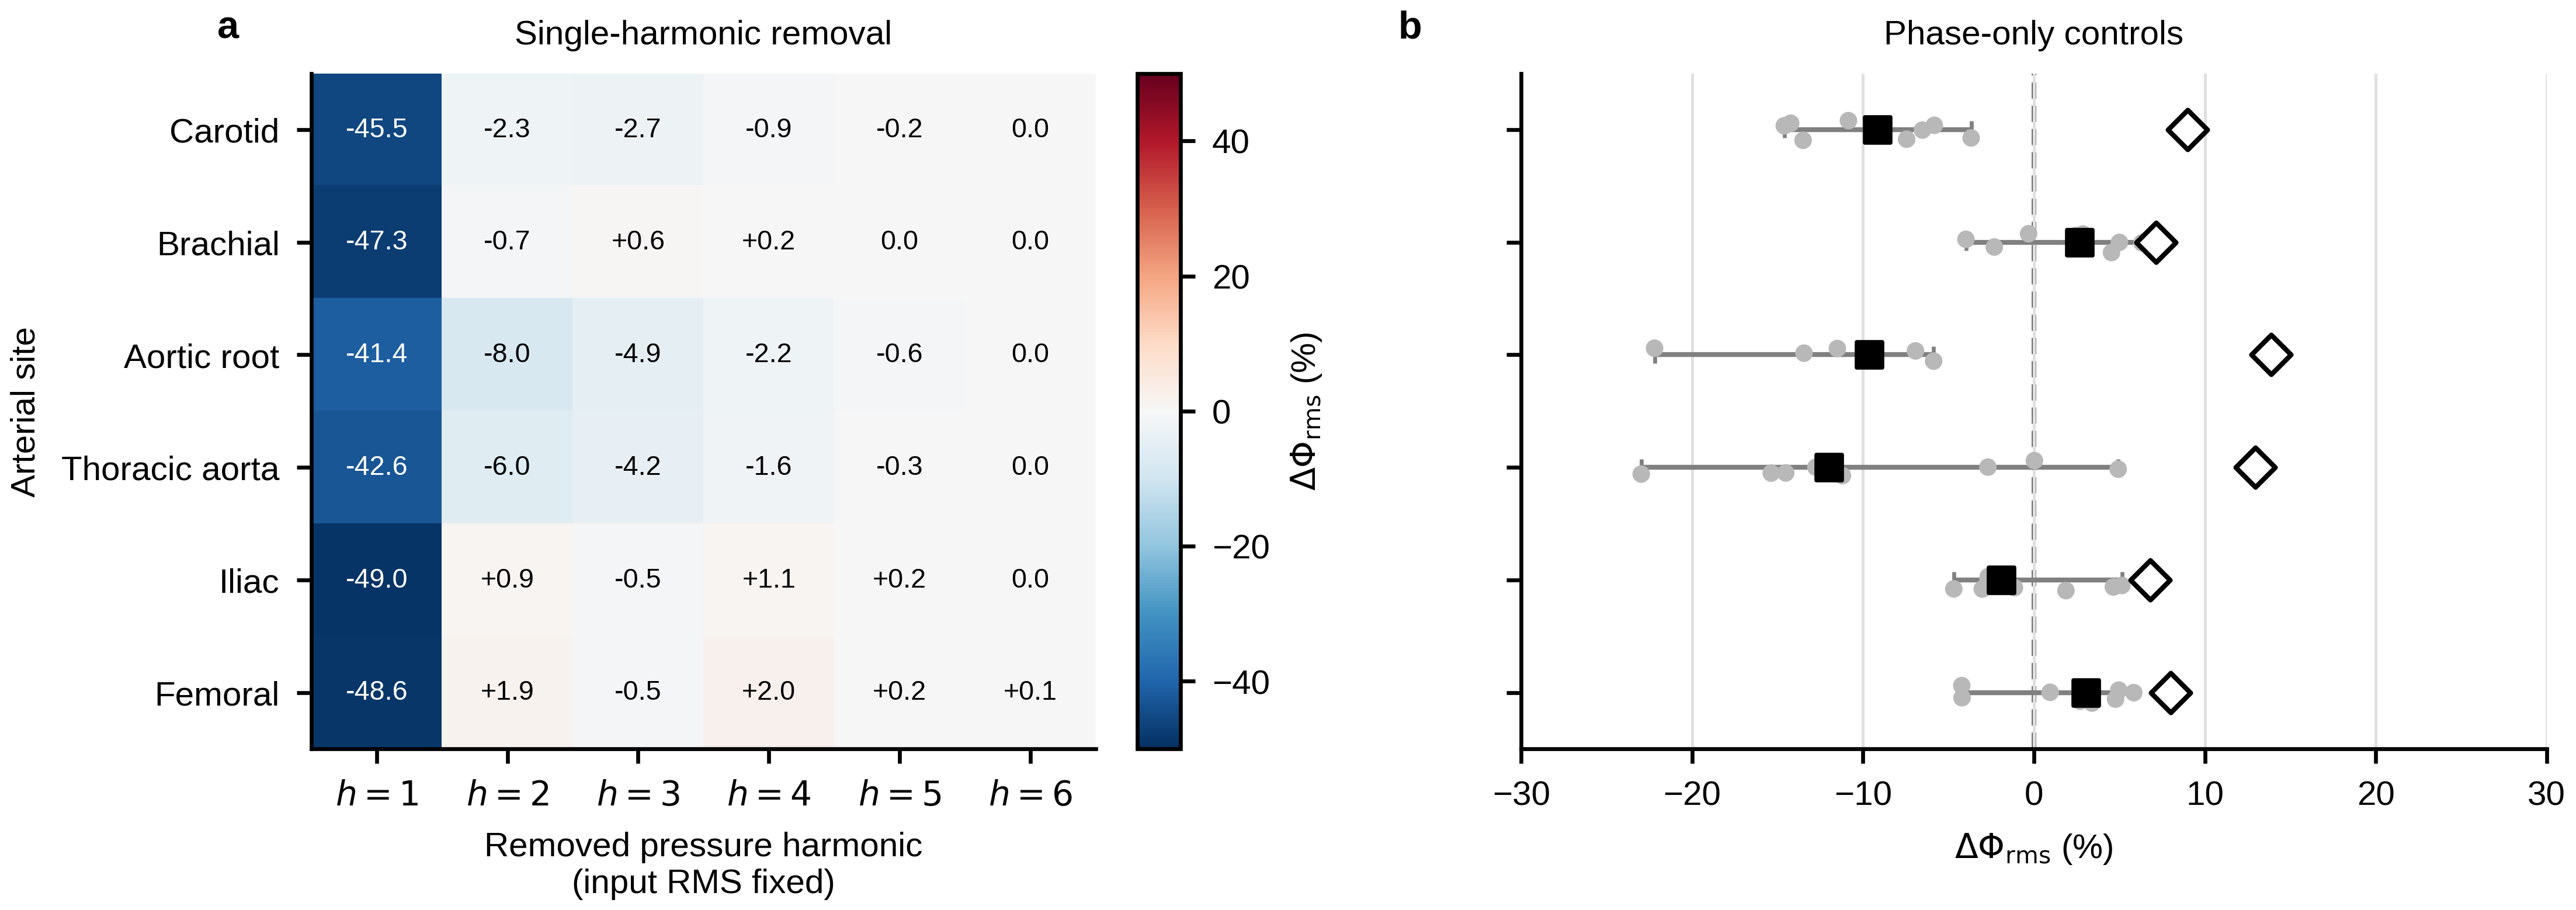

In [34]:
# Final Step 4 — Figure 4, corrected and layout-validated
# Deterministic waveform interventions:
# single-harmonic removal at fixed input RMS and phase-only controls.
from IPython.display import Image, display
from matplotlib.colors import TwoSlopeNorm

required_globals = [
    "ANALYSIS_ROOT",
    "CONTROLS",
    "ARTICLE_WIDTH_MM",
    "RASTER_DPI",
    "DIV_CMAP",
    "mm_to_inches",
    "panel_label",
    "clean_axis",
    "np",
    "pd",
    "plt",
]

missing_globals = [
    name for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        "Run the existing load and publication-style cells first. "
        f"Missing globals: {missing_globals}"
    )

FINAL_FIGURE_ROOT = ANALYSIS_ROOT / "figures_final"
FINAL_SOURCE_ROOT = FINAL_FIGURE_ROOT / "figure_sources"

FINAL_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_SOURCE_ROOT.mkdir(parents=True, exist_ok=True)

# Approximate superior-to-inferior anatomical order.
ANATOMICAL_ORDER = [
    "carotid",
    "brachial",
    "aortic_root",
    "thoracic_aorta",
    "iliac",
    "femoral",
]

ARTERY_LABELS = {
    "carotid": "Carotid",
    "brachial": "Brachial",
    "aortic_root": "Aortic root",
    "thoracic_aorta": "Thoracic aorta",
    "iliac": "Iliac",
    "femoral": "Femoral",
}

# ============================================================
# 1. Single-harmonic removal at fixed input RMS
# ============================================================
harmonic_removal = CONTROLS[
    CONTROLS["control"]
    .astype(str)
    .str.fullmatch(r"remove_h[1-6]_rms_matched")
].copy()

harmonic_removal["harmonic"] = (
    harmonic_removal["control"]
    .str.extract(r"remove_h([1-6])")[0]
    .astype(int)
)

harmonic_removal["change_percent"] = (
    100.0
    * (
        harmonic_removal["relative_to_native"].astype(float)
        - 1.0
    )
)

removal_matrix = (
    harmonic_removal
    .pivot(
        index="artery_id",
        columns="harmonic",
        values="change_percent",
    )
    .loc[
        ANATOMICAL_ORDER,
        [1, 2, 3, 4, 5, 6],
    ]
)

if removal_matrix.shape != (6, 6):
    raise ValueError(
        "Expected one fixed-RMS removal result for every "
        "artery–harmonic combination."
    )

removal_values = removal_matrix.to_numpy(float)

if np.any(~np.isfinite(removal_values)):
    raise ValueError(
        "The harmonic-removal matrix contains non-finite values."
    )

# ============================================================
# 2. Phase-only deterministic controls
# ============================================================
phase_controls = CONTROLS[
    CONTROLS["family"].astype(str).str.lower() == "phase"
].copy()

phase_controls["change_percent"] = (
    100.0
    * (
        phase_controls["relative_to_native"].astype(float)
        - 1.0
    )
)

random_phase = phase_controls[
    phase_controls["control"]
    .astype(str)
    .str.fullmatch(r"phase_random_\d+")
].copy()

common_phase = phase_controls[
    phase_controls["control"].astype(str)
    == "common_phase_pi_over_4"
].copy()

random_counts = (
    random_phase
    .groupby("artery_id")
    .size()
    .reindex(ANATOMICAL_ORDER)
)

if random_counts.isna().any():
    raise ValueError(
        "One or more arteries are missing random-phase controls."
    )

if random_counts.nunique() != 1:
    raise ValueError(
        "Each artery must contain the same number of random-phase controls."
    )

number_of_random_controls = int(random_counts.iloc[0])

if number_of_random_controls != 8:
    raise ValueError(
        "Expected eight random-phase controls per artery, "
        f"found {number_of_random_controls}."
    )

common_counts = (
    common_phase
    .groupby("artery_id")
    .size()
    .reindex(ANATOMICAL_ORDER)
)

if common_counts.isna().any() or not np.all(common_counts.to_numpy() == 1):
    raise ValueError(
        "Expected exactly one common-phase control for each artery."
    )

# ============================================================
# 3. Export plotted source data
# ============================================================
phase_summary_rows = []

for artery_id in ANATOMICAL_ORDER:
    random_values = (
        random_phase.loc[
            random_phase["artery_id"] == artery_id,
            "change_percent",
        ]
        .astype(float)
        .to_numpy()
    )

    common_value = float(
        common_phase.loc[
            common_phase["artery_id"] == artery_id,
            "change_percent",
        ].iloc[0]
    )

    phase_summary_rows.append(
        {
            "artery_id": artery_id,
            "random_min_percent": float(np.min(random_values)),
            "random_q25_percent": float(np.quantile(random_values, 0.25)),
            "random_median_percent": float(np.median(random_values)),
            "random_q75_percent": float(np.quantile(random_values, 0.75)),
            "random_max_percent": float(np.max(random_values)),
            "common_phase_pi_over_4_percent": common_value,
            "number_of_random_controls": int(len(random_values)),
        }
    )

phase_summary = pd.DataFrame(phase_summary_rows)

removal_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_4_harmonic_removal_final_source.csv"
)

phase_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_4_phase_controls_final_source.csv"
)

phase_summary_path = (
    FINAL_SOURCE_ROOT
    / "figure_4_phase_summary_final_source.csv"
)

harmonic_removal.to_csv(
    removal_source_path,
    index=False,
)

phase_controls.to_csv(
    phase_source_path,
    index=False,
)

phase_summary.to_csv(
    phase_summary_path,
    index=False,
)

# ============================================================
# 4. Figure layout
# ============================================================
fig = plt.figure(
    figsize=(
        mm_to_inches(ARTICLE_WIDTH_MM),
        mm_to_inches(68.0),
    )
)

# Two primary panels. Panel a contains its own dedicated
# heatmap and colorbar sub-grid.
outer_grid = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.00, 1.18],
    left=0.085,
    right=0.985,
    bottom=0.18,
    top=0.90,
    wspace=0.36,
)

left_grid = outer_grid[0, 0].subgridspec(
    1,
    2,
    width_ratios=[1.00, 0.055],
    wspace=0.10,
)

ax_a = fig.add_subplot(left_grid[0, 0])
cax = fig.add_subplot(left_grid[0, 1])
ax_b = fig.add_subplot(outer_grid[0, 1])

y = np.arange(len(ANATOMICAL_ORDER))

artery_labels = [
    ARTERY_LABELS[artery_id]
    for artery_id in ANATOMICAL_ORDER
]

# ============================================================
# Panel a — harmonic-removal heatmap
# ============================================================
removal_limit = (
    5.0
    * np.ceil(
        np.max(np.abs(removal_values))
        / 5.0
    )
)

image = ax_a.imshow(
    removal_values,
    cmap=DIV_CMAP,
    norm=TwoSlopeNorm(
        vmin=-removal_limit,
        vcenter=0.0,
        vmax=removal_limit,
    ),
    interpolation="nearest",
    aspect="auto",
    origin="upper",
)

ax_a.set_xticks(
    np.arange(6),
    [
        rf"$h={harmonic}$"
        for harmonic in range(1, 7)
    ],
)

ax_a.set_yticks(
    y,
    artery_labels,
)

ax_a.set_xlabel(
    "Removed pressure harmonic\n(input RMS fixed)"
)

ax_a.set_ylabel(
    "Arterial site"
)

ax_a.set_title(
    "Single-harmonic removal"
)

# Do not invert this axis. origin="upper" places carotid at top.
ax_a.set_ylim(5.5, -0.5)

for row in range(6):
    for column in range(6):
        value = float(removal_values[row, column])

        # Prevent the display of -0.0 at one-decimal precision.
        display_value = (
            0.0
            if abs(value) < 0.05
            else value
        )

        label = (
            "0.0"
            if display_value == 0.0
            else f"{display_value:+.1f}"
        )

        ax_a.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            fontsize=5.6,
            color=(
                "white"
                if abs(value) > 0.56 * removal_limit
                else "black"
            ),
        )

colourbar = fig.colorbar(
    image,
    cax=cax,
)

colourbar.set_label(
    r"$\Delta\Phi_{\mathrm{rms}}$ (%)"
)

panel_label(
    ax_a,
    "a",
)

# ============================================================
# Panel b — phase-only controls
# ============================================================
rng = np.random.default_rng(20260731)

all_random_values = []
all_common_values = []

for position, artery_id in enumerate(ANATOMICAL_ORDER):
    random_values = (
        random_phase.loc[
            random_phase["artery_id"] == artery_id,
            "change_percent",
        ]
        .astype(float)
        .to_numpy()
    )

    common_value = float(
        common_phase.loc[
            common_phase["artery_id"] == artery_id,
            "change_percent",
        ].iloc[0]
    )

    minimum = float(np.min(random_values))
    maximum = float(np.max(random_values))
    median = float(np.median(random_values))

    all_random_values.extend(
        random_values.tolist()
    )

    all_common_values.append(
        common_value
    )

    # Observed range of the eight deterministic controls.
    ax_b.hlines(
        position,
        minimum,
        maximum,
        color="0.50",
        linewidth=1.0,
        zorder=1,
    )

    ax_b.vlines(
        [minimum, maximum],
        position - 0.075,
        position + 0.075,
        color="0.50",
        linewidth=0.8,
        zorder=1,
    )

    # Individual deterministic phase controls.
    jitter = rng.uniform(
        -0.095,
        0.095,
        size=len(random_values),
    )

    ax_b.scatter(
        random_values,
        np.full(len(random_values), position) + jitter,
        s=13,
        facecolor="0.72",
        edgecolor="none",
        zorder=2,
    )

    # Median across the eight controls.
    ax_b.scatter(
        median,
        position,
        s=28,
        marker="s",
        facecolor="black",
        edgecolor="black",
        linewidth=0.8,
        zorder=4,
    )

    # Prescribed common phase π/4.
    ax_b.scatter(
        common_value,
        position,
        s=33,
        marker="D",
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=5,
    )

maximum_absolute_phase_change = max(
    np.max(np.abs(all_random_values)),
    np.max(np.abs(all_common_values)),
    1.0,
)

phase_limit = (
    5.0
    * np.ceil(
        1.10
        * maximum_absolute_phase_change
        / 5.0
    )
)

ax_b.axvline(
    0.0,
    color="0.35",
    linewidth=0.9,
    linestyle="--",
    zorder=0,
)

ax_b.set_xlim(
    -phase_limit,
    phase_limit,
)

ax_b.set_xticks(
    np.arange(
        -phase_limit,
        phase_limit + 0.1,
        10.0,
    )
)

ax_b.set_ylim(
    5.5,
    -0.5,
)

ax_b.set_yticks(y)
ax_b.set_yticklabels([])

ax_b.set_xlabel(
    r"$\Delta\Phi_{\mathrm{rms}}$ (%)"
)

ax_b.set_title(
    "Phase-only controls"
)

ax_b.grid(
    axis="x",
    color="0.86",
    linewidth=0.7,
)

clean_axis(
    ax_b,
    "x",
)

panel_label(
    ax_b,
    "b",
)

# ============================================================
# 5. Export and display
# ============================================================
png_path = (
    FINAL_FIGURE_ROOT
    / "figure_4_waveform_interventions_final.png"
)

fig.savefig(
    png_path,
    dpi=RASTER_DPI,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.03,
)

plt.close(fig)

print(f"Final Figure 4 saved to: {png_path}")
print(f"Harmonic-removal source saved to: {removal_source_path}")
print(f"Phase-control source saved to: {phase_source_path}")
print(f"Phase summary saved to: {phase_summary_path}")
print(
    "Caption definition: grey points denote the eight deterministic "
    "random-phase controls; horizontal lines show their observed range; "
    "black squares show their median; open diamonds show the prescribed "
    "common phase π/4."
)

display(
    Image(
        filename=str(png_path)
    )
)

Final Figure 5 saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_5_reduced_law_final.png
Prediction source saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_5_predictions_final_source.csv
Exponent source saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_5_exponents_final_source.csv
Singular-value source saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_5_singular_values_final_source.csv
Artery-error source saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_5_artery_errors_final_source.csv
Caption definitions: dashed diagonal lines in panel 

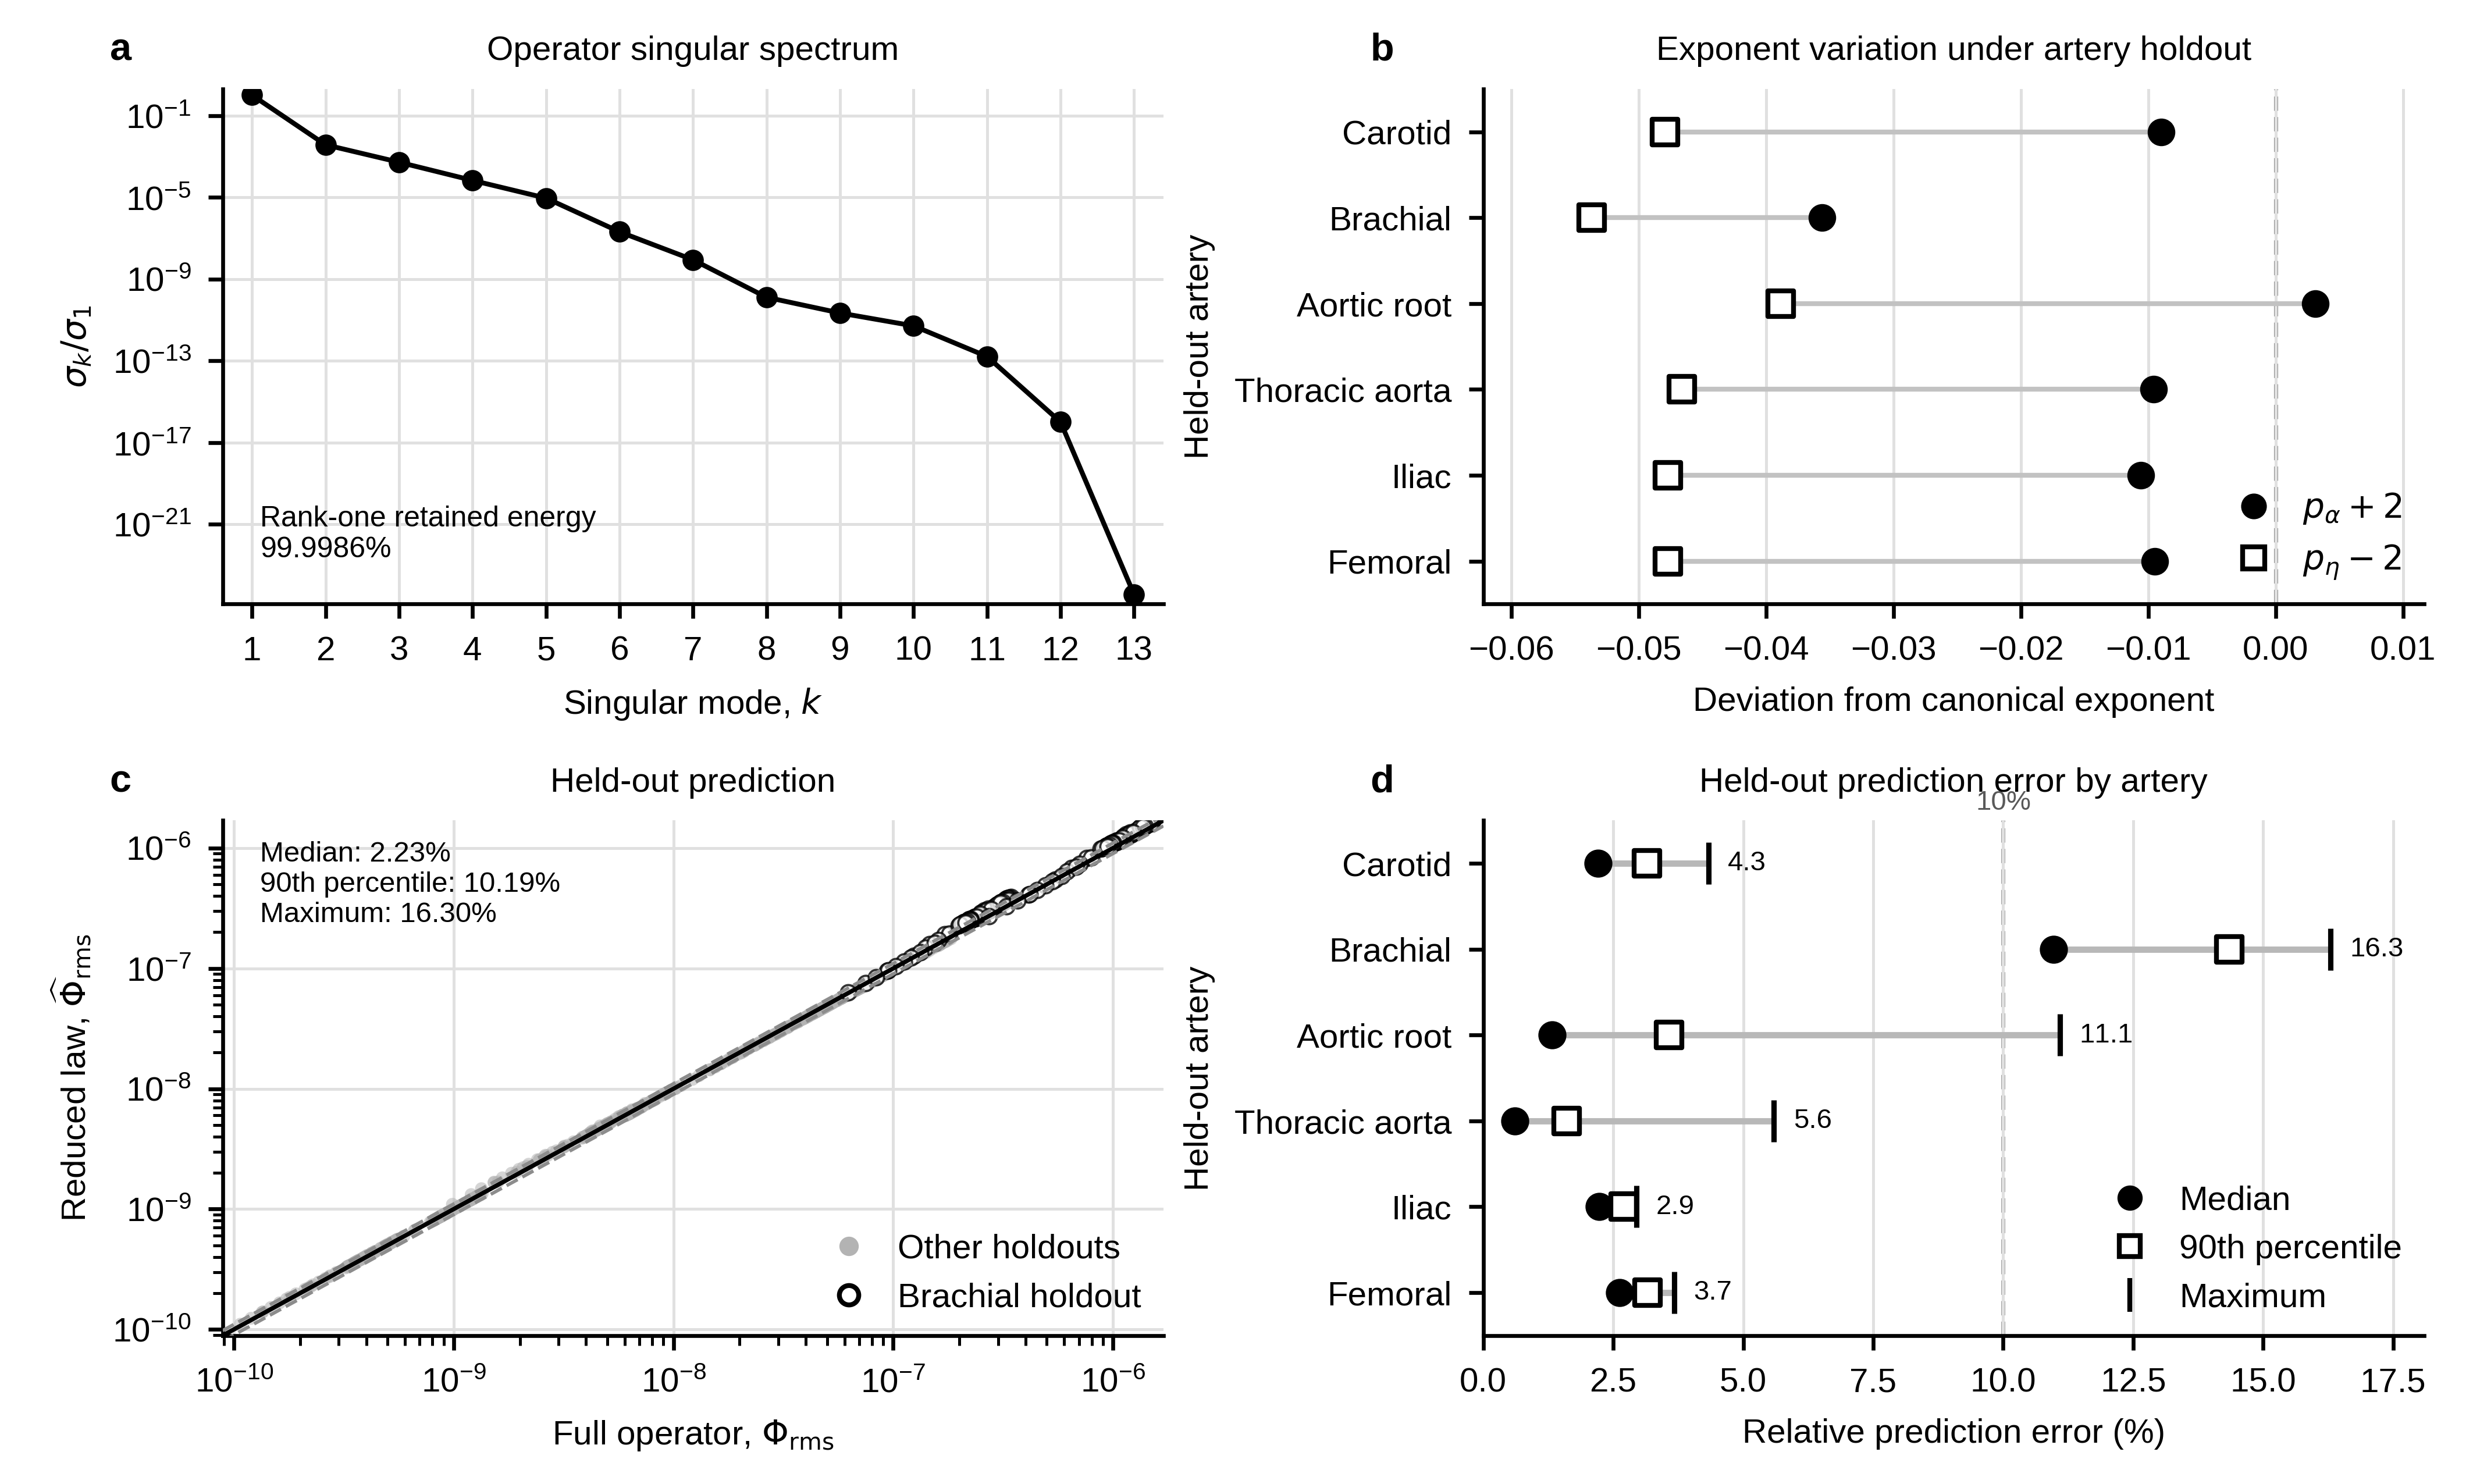

In [39]:
# Final Step 5 — Figure 5
# Reduced-law structure and held-out validation:
# singular spectrum, exponent variation under artery holdout,
# full prediction agreement, and artery-resolved error.
from IPython.display import Image, display
from matplotlib.lines import Line2D

plt.close("all")

required_globals = [
    "ANALYSIS_ROOT",
    "PREDICTIONS",
    "SUMMARY",
    "OPERATOR_ARCHIVE",
    "ARTICLE_WIDTH_MM",
    "RASTER_DPI",
    "mm_to_inches",
    "panel_label",
    "clean_axis",
    "np",
    "pd",
    "plt",
]

missing_globals = [
    name for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        "Run the existing load and publication-style cells first. "
        f"Missing globals: {missing_globals}"
    )

FINAL_FIGURE_ROOT = ANALYSIS_ROOT / "figures_final"
FINAL_SOURCE_ROOT = FINAL_FIGURE_ROOT / "figure_sources"

FINAL_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_SOURCE_ROOT.mkdir(parents=True, exist_ok=True)

ANATOMICAL_ORDER = [
    "carotid",
    "brachial",
    "aortic_root",
    "thoracic_aorta",
    "iliac",
    "femoral",
]

ARTERY_LABELS = {
    "carotid": "Carotid",
    "brachial": "Brachial",
    "aortic_root": "Aortic root",
    "thoracic_aorta": "Thoracic aorta",
    "iliac": "Iliac",
    "femoral": "Femoral",
}

# ============================================================
# 1. Validate held-out prediction data
# ============================================================
required_prediction_columns = {
    "held_out_artery",
    "family",
    "exact_phi_rms",
    "predicted_phi_rms",
    "relative_error",
}

missing_prediction_columns = sorted(
    required_prediction_columns.difference(PREDICTIONS.columns)
)

if missing_prediction_columns:
    raise KeyError(
        "reduced_law_validation.csv is missing columns: "
        f"{missing_prediction_columns}"
    )

prediction_data = PREDICTIONS.copy()

prediction_data["exact_phi_rms"] = pd.to_numeric(
    prediction_data["exact_phi_rms"],
    errors="coerce",
)

prediction_data["predicted_phi_rms"] = pd.to_numeric(
    prediction_data["predicted_phi_rms"],
    errors="coerce",
)

prediction_data["relative_error_percent"] = (
    100.0
    * pd.to_numeric(
        prediction_data["relative_error"],
        errors="coerce",
    )
)

valid_prediction_mask = (
    np.isfinite(prediction_data["exact_phi_rms"])
    & np.isfinite(prediction_data["predicted_phi_rms"])
    & np.isfinite(prediction_data["relative_error_percent"])
    & (prediction_data["exact_phi_rms"] > 0.0)
    & (prediction_data["predicted_phi_rms"] > 0.0)
    & (prediction_data["relative_error_percent"] >= 0.0)
)

prediction_data = (
    prediction_data.loc[valid_prediction_mask]
    .reset_index(drop=True)
)

if len(prediction_data) != 1068:
    raise ValueError(
        "Expected 1,068 valid held-out predictions, "
        f"found {len(prediction_data)}."
    )

if set(prediction_data["held_out_artery"]) != set(ANATOMICAL_ORDER):
    raise ValueError(
        "The prediction table does not contain the expected "
        "six held-out arteries."
    )

# ============================================================
# 2. Singular-value spectrum
# ============================================================
if "singular_values" not in OPERATOR_ARCHIVE.files:
    raise KeyError(
        "operator_archive.npz is missing 'singular_values'."
    )

singular_values = np.abs(
    np.asarray(
        OPERATOR_ARCHIVE["singular_values"],
        dtype=float,
    )
)

if singular_values.ndim != 1 or len(singular_values) < 2:
    raise ValueError(
        "The singular-value spectrum is incomplete."
    )

if np.any(~np.isfinite(singular_values)):
    raise ValueError(
        "The singular-value spectrum contains non-finite entries."
    )

if singular_values[0] <= 0.0:
    raise ValueError(
        "The leading singular value must be positive."
    )

singular_ratio = singular_values / singular_values[0]
mode_numbers = np.arange(1, len(singular_ratio) + 1)

positive_singular_ratio = singular_ratio[singular_ratio > 0.0]

if len(positive_singular_ratio) == 0:
    raise ValueError(
        "No positive normalized singular values were found."
    )

singular_plot_floor = max(
    float(positive_singular_ratio.min()) / 3.0,
    1.0e-30,
)

singular_ratio_for_plot = np.maximum(
    singular_ratio,
    singular_plot_floor,
)

# ============================================================
# 3. Reduced-law summary and holdout exponents
# ============================================================
if "reduced_law" not in SUMMARY:
    raise KeyError(
        "analysis_summary.json is missing 'reduced_law'."
    )

reduced_law = SUMMARY["reduced_law"]

required_summary_fields = {
    "retained_energy",
    "leave_one_out_exponents",
    "median_relative_error",
    "p90_relative_error",
    "maximum_relative_error",
}

missing_summary_fields = sorted(
    required_summary_fields.difference(reduced_law)
)

if missing_summary_fields:
    raise KeyError(
        "The reduced-law summary is missing fields: "
        f"{missing_summary_fields}"
    )

rank_one_retained_energy = float(
    reduced_law["retained_energy"]
)

exponent_data = pd.DataFrame(
    reduced_law["leave_one_out_exponents"]
)

required_exponent_columns = {
    "held_out_artery",
    "alpha_exponent",
    "eta_exponent",
    "prefactor",
    "retained_energy",
}

missing_exponent_columns = sorted(
    required_exponent_columns.difference(exponent_data.columns)
)

if missing_exponent_columns:
    raise KeyError(
        "The holdout-exponent table is missing columns: "
        f"{missing_exponent_columns}"
    )

exponent_data = (
    exponent_data
    .set_index("held_out_artery")
    .loc[ANATOMICAL_ORDER]
    .reset_index()
)

exponent_data["alpha_deviation"] = (
    pd.to_numeric(
        exponent_data["alpha_exponent"],
        errors="raise",
    )
    + 2.0
)

exponent_data["eta_deviation"] = (
    pd.to_numeric(
        exponent_data["eta_exponent"],
        errors="raise",
    )
    - 2.0
)

# ============================================================
# 4. Prediction-error summaries
# ============================================================
artery_error = (
    prediction_data
    .groupby("held_out_artery")["relative_error_percent"]
    .agg(
        median="median",
        p90=lambda values: float(values.quantile(0.90)),
        maximum="max",
    )
    .reindex(ANATOMICAL_ORDER)
    .reset_index()
)

if artery_error[["median", "p90", "maximum"]].isna().any().any():
    raise ValueError(
        "One or more artery-specific error summaries are missing."
    )

overall_median = float(
    prediction_data["relative_error_percent"].median()
)

overall_p90 = float(
    prediction_data["relative_error_percent"].quantile(0.90)
)

overall_maximum = float(
    prediction_data["relative_error_percent"].max()
)

summary_median = (
    100.0
    * float(reduced_law["median_relative_error"])
)

summary_p90 = (
    100.0
    * float(reduced_law["p90_relative_error"])
)

summary_maximum = (
    100.0
    * float(reduced_law["maximum_relative_error"])
)

if not np.isclose(
    overall_median,
    summary_median,
    rtol=1.0e-6,
    atol=1.0e-8,
):
    raise RuntimeError(
        "Calculated median error does not match analysis_summary.json."
    )

if not np.isclose(
    overall_p90,
    summary_p90,
    rtol=1.0e-6,
    atol=1.0e-8,
):
    raise RuntimeError(
        "Calculated 90th-percentile error does not match "
        "analysis_summary.json."
    )

if not np.isclose(
    overall_maximum,
    summary_maximum,
    rtol=1.0e-6,
    atol=1.0e-8,
):
    raise RuntimeError(
        "Calculated maximum error does not match analysis_summary.json."
    )

# ============================================================
# 5. Export plotted source data
# ============================================================
prediction_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_5_predictions_final_source.csv"
)

exponent_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_5_exponents_final_source.csv"
)

singular_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_5_singular_values_final_source.csv"
)

error_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_5_artery_errors_final_source.csv"
)

prediction_data.to_csv(
    prediction_source_path,
    index=False,
)

exponent_data.to_csv(
    exponent_source_path,
    index=False,
)

pd.DataFrame(
    {
        "mode": mode_numbers,
        "singular_value": singular_values,
        "sigma_over_sigma_1": singular_ratio,
    }
).to_csv(
    singular_source_path,
    index=False,
)

artery_error.to_csv(
    error_source_path,
    index=False,
)

# ============================================================
# 6. Figure layout
# ============================================================
fig = plt.figure(
    figsize=(
        mm_to_inches(ARTICLE_WIDTH_MM),
        mm_to_inches(108.0),
    )
)

grid = fig.add_gridspec(
    2,
    2,
    left=0.09,
    right=0.98,
    bottom=0.10,
    top=0.94,
    wspace=0.34,
    hspace=0.42,
)

ax_a = fig.add_subplot(grid[0, 0])
ax_b = fig.add_subplot(grid[0, 1])
ax_c = fig.add_subplot(grid[1, 0])
ax_d = fig.add_subplot(grid[1, 1])

# ============================================================
# Panel a — singular spectrum
# ============================================================
ax_a.semilogy(
    mode_numbers,
    singular_ratio_for_plot,
    marker="o",
    markersize=3.4,
    linewidth=1.0,
    color="black",
)

ax_a.set_xlim(
    0.6,
    len(mode_numbers) + 0.4,
)

ax_a.set_ylim(
    singular_plot_floor,
    2.0,
)

ax_a.set_xticks(
    mode_numbers
)

ax_a.set_xlabel(
    "Singular mode, $k$"
)

ax_a.set_ylabel(
    r"$\sigma_k/\sigma_1$"
)

ax_a.set_title(
    "Operator singular spectrum"
)

ax_a.text(
    0.04,
    0.08,
    "Rank-one retained energy\n"
    f"{100.0 * rank_one_retained_energy:.4f}%",
    transform=ax_a.transAxes,
    ha="left",
    va="bottom",
    fontsize=6.0,
)

clean_axis(
    ax_a,
    "both",
)

panel_label(
    ax_a,
    "a",
)

# ============================================================
# Panel b — exponent variation under artery holdout
# ============================================================
artery_positions = np.arange(
    len(ANATOMICAL_ORDER)
)

alpha_deviation = (
    exponent_data["alpha_deviation"]
    .to_numpy(float)
)

eta_deviation = (
    exponent_data["eta_deviation"]
    .to_numpy(float)
)

for position, alpha_value, eta_value in zip(
    artery_positions,
    alpha_deviation,
    eta_deviation,
):
    ax_b.hlines(
        position,
        min(alpha_value, eta_value),
        max(alpha_value, eta_value),
        color="0.76",
        linewidth=1.0,
        zorder=1,
    )

ax_b.scatter(
    alpha_deviation,
    artery_positions,
    s=24,
    marker="o",
    facecolor="black",
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)

ax_b.scatter(
    eta_deviation,
    artery_positions,
    s=27,
    marker="s",
    facecolor="white",
    edgecolor="black",
    linewidth=1.0,
    zorder=3,
)

ax_b.axvline(
    0.0,
    color="0.45",
    linestyle="--",
    linewidth=0.8,
    zorder=0,
)

deviation_minimum = float(
    min(
        alpha_deviation.min(),
        eta_deviation.min(),
        0.0,
    )
)

deviation_maximum = float(
    max(
        alpha_deviation.max(),
        eta_deviation.max(),
        0.0,
    )
)

deviation_span = (
    deviation_maximum
    - deviation_minimum
)

if deviation_span <= 0.0:
    deviation_span = 0.01

ax_b.set_xlim(
    deviation_minimum - 0.15 * deviation_span,
    deviation_maximum + 0.15 * deviation_span,
)

ax_b.set_ylim(
    5.5,
    -0.5,
)

ax_b.set_yticks(
    artery_positions,
    [
        ARTERY_LABELS[artery_id]
        for artery_id in ANATOMICAL_ORDER
    ],
)

ax_b.set_xlabel(
    "Deviation from canonical exponent"
)

ax_b.set_ylabel(
    "Held-out artery"
)

ax_b.set_title(
    "Exponent variation under artery holdout"
)

exponent_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=4.3,
        label=r"$p_{\alpha}+2$",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4.5,
        label=r"$p_{\eta}-2$",
    ),
]

ax_b.legend(
    handles=exponent_legend,
    loc="lower right",
    frameon=False,
    handletextpad=0.45,
    borderaxespad=0.25,
)

clean_axis(
    ax_b,
    "x",
)

panel_label(
    ax_b,
    "b",
)

# ============================================================
# Panel c — full operator versus held-out prediction
# ============================================================
non_brachial_mask = (
    prediction_data["held_out_artery"]
    != "brachial"
)

brachial_mask = (
    prediction_data["held_out_artery"]
    == "brachial"
)

ax_c.scatter(
    prediction_data.loc[
        non_brachial_mask,
        "exact_phi_rms",
    ],
    prediction_data.loc[
        non_brachial_mask,
        "predicted_phi_rms",
    ],
    s=7,
    facecolor="0.70",
    edgecolor="none",
    alpha=0.55,
    rasterized=True,
    zorder=1,
)

ax_c.scatter(
    prediction_data.loc[
        brachial_mask,
        "exact_phi_rms",
    ],
    prediction_data.loc[
        brachial_mask,
        "predicted_phi_rms",
    ],
    s=10,
    facecolor="white",
    edgecolor="black",
    linewidth=0.45,
    alpha=0.80,
    rasterized=True,
    zorder=2,
)

exact_values = (
    prediction_data["exact_phi_rms"]
    .to_numpy(float)
)

predicted_values = (
    prediction_data["predicted_phi_rms"]
    .to_numpy(float)
)

lower_limit = float(
    min(
        exact_values.min(),
        predicted_values.min(),
    )
)

upper_limit = float(
    max(
        exact_values.max(),
        predicted_values.max(),
    )
)

guide = np.geomspace(
    lower_limit,
    upper_limit,
    300,
)

ax_c.plot(
    guide,
    guide,
    color="black",
    linewidth=0.9,
    zorder=4,
)

ax_c.plot(
    guide,
    1.10 * guide,
    color="0.55",
    linestyle="--",
    linewidth=0.7,
    zorder=3,
)

ax_c.plot(
    guide,
    0.90 * guide,
    color="0.55",
    linestyle="--",
    linewidth=0.7,
    zorder=3,
)

ax_c.set_xscale("log")
ax_c.set_yscale("log")

ax_c.set_xlim(
    lower_limit,
    upper_limit,
)

ax_c.set_ylim(
    lower_limit,
    upper_limit,
)

ax_c.set_xlabel(
    r"Full operator, $\Phi_{\mathrm{rms}}$"
)

ax_c.set_ylabel(
    r"Reduced law, $\widehat{\Phi}_{\mathrm{rms}}$"
)

ax_c.set_title(
    "Held-out prediction"
)

ax_c.text(
    0.04,
    0.96,
    f"Median: {overall_median:.2f}%\n"
    f"90th percentile: {overall_p90:.2f}%\n"
    f"Maximum: {overall_maximum:.2f}%",
    transform=ax_c.transAxes,
    ha="left",
    va="top",
    fontsize=5.9,
)

prediction_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="0.70",
        markeredgecolor="none",
        markersize=4.0,
        label="Other holdouts",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4.0,
        label="Brachial holdout",
    ),
]

ax_c.legend(
    handles=prediction_legend,
    loc="lower right",
    frameon=False,
    handletextpad=0.45,
    borderaxespad=0.25,
)

clean_axis(
    ax_c,
    "both",
)

panel_label(
    ax_c,
    "c",
)

# ============================================================
# Panel d — held-out prediction error by artery
# ============================================================
error_positions = np.arange(
    len(ANATOMICAL_ORDER)
)

for position, row in enumerate(
    artery_error.itertuples(index=False)
):
    # Segment extends from median to maximum.
    ax_d.hlines(
        position,
        row.median,
        row.maximum,
        color="0.72",
        linewidth=1.3,
        zorder=1,
    )

    ax_d.scatter(
        row.median,
        position,
        s=23,
        marker="o",
        facecolor="black",
        edgecolor="black",
        zorder=3,
    )

    ax_d.scatter(
        row.p90,
        position,
        s=27,
        marker="s",
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=3,
    )

    ax_d.scatter(
        row.maximum,
        position,
        s=75,
        marker="|",
        color="black",
        linewidth=1.1,
        zorder=3,
    )

    ax_d.annotate(
        f"{row.maximum:.1f}",
        xy=(row.maximum, position),
        xytext=(4, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=5.7,
    )

ax_d.axvline(
    10.0,
    color="0.55",
    linestyle="--",
    linewidth=0.8,
    zorder=0,
)

# Explicitly identify the reference threshold.
ax_d.text(
    10.0,
    1.01,
    "10%",
    transform=ax_d.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=5.7,
    color="0.35",
)

error_upper = max(
    18.0,
    float(artery_error["maximum"].max()) + 1.8,
)

ax_d.set_xlim(
    0.0,
    error_upper,
)

ax_d.set_ylim(
    5.5,
    -0.5,
)

ax_d.set_yticks(
    error_positions,
    [
        ARTERY_LABELS[artery_id]
        for artery_id in ANATOMICAL_ORDER
    ],
)

ax_d.set_xlabel(
    "Relative prediction error (%)"
)

ax_d.set_ylabel(
    "Held-out artery"
)

ax_d.set_title(
    "Held-out prediction error by artery"
)

error_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=4.2,
        label="Median",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4.4,
        label="90th percentile",
    ),
    Line2D(
        [0],
        [0],
        marker="|",
        linestyle="none",
        color="black",
        markersize=7.0,
        label="Maximum",
    ),
]

ax_d.legend(
    handles=error_legend,
    loc="lower right",
    frameon=False,
    handletextpad=0.45,
    borderaxespad=0.25,
)

clean_axis(
    ax_d,
    "x",
)

panel_label(
    ax_d,
    "d",
)

# ============================================================
# 7. Render validation, save and display
# ============================================================
png_path = (
    FINAL_FIGURE_ROOT
    / "figure_5_reduced_law_final.png"
)

# Validate all text and mathematical expressions before export.
try:
    fig.canvas.draw()
except Exception:
    plt.close(fig)
    raise

fig.savefig(
    png_path,
    dpi=RASTER_DPI,
    facecolor="white",
    transparent=False,
)

plt.close(fig)

print(f"Final Figure 5 saved to: {png_path}")
print(f"Prediction source saved to: {prediction_source_path}")
print(f"Exponent source saved to: {exponent_source_path}")
print(f"Singular-value source saved to: {singular_source_path}")
print(f"Artery-error source saved to: {error_source_path}")
print(
    "Caption definitions: dashed diagonal lines in panel c denote "
    "±10% relative prediction bounds; open points denote brachial "
    "holdout predictions. In panel d, each horizontal segment extends "
    "from the median to the maximum error."
)

display(
    Image(
        filename=str(png_path)
    )
)

Final Figure S1 saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_S1_constitutive_robustness_final.png
Case-level source saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_S1_constitutive_robustness_final_cases.csv
Path summary saved to: /content/drive/MyDrive/picoNewton_waveform_susceptibility/runs/20260731T083707Z_a3916469/analysis/figures_final/figure_sources/figure_S1_constitutive_robustness_final_summary.csv
Caption definitions: small grey symbols denote individual arterial cases; large outlined symbols denote constitutive-path medians. Amplitude departure is measured relative to the reciprocal path. The vertical axis uses symmetric-logarithmic scaling with a linear region around zero.


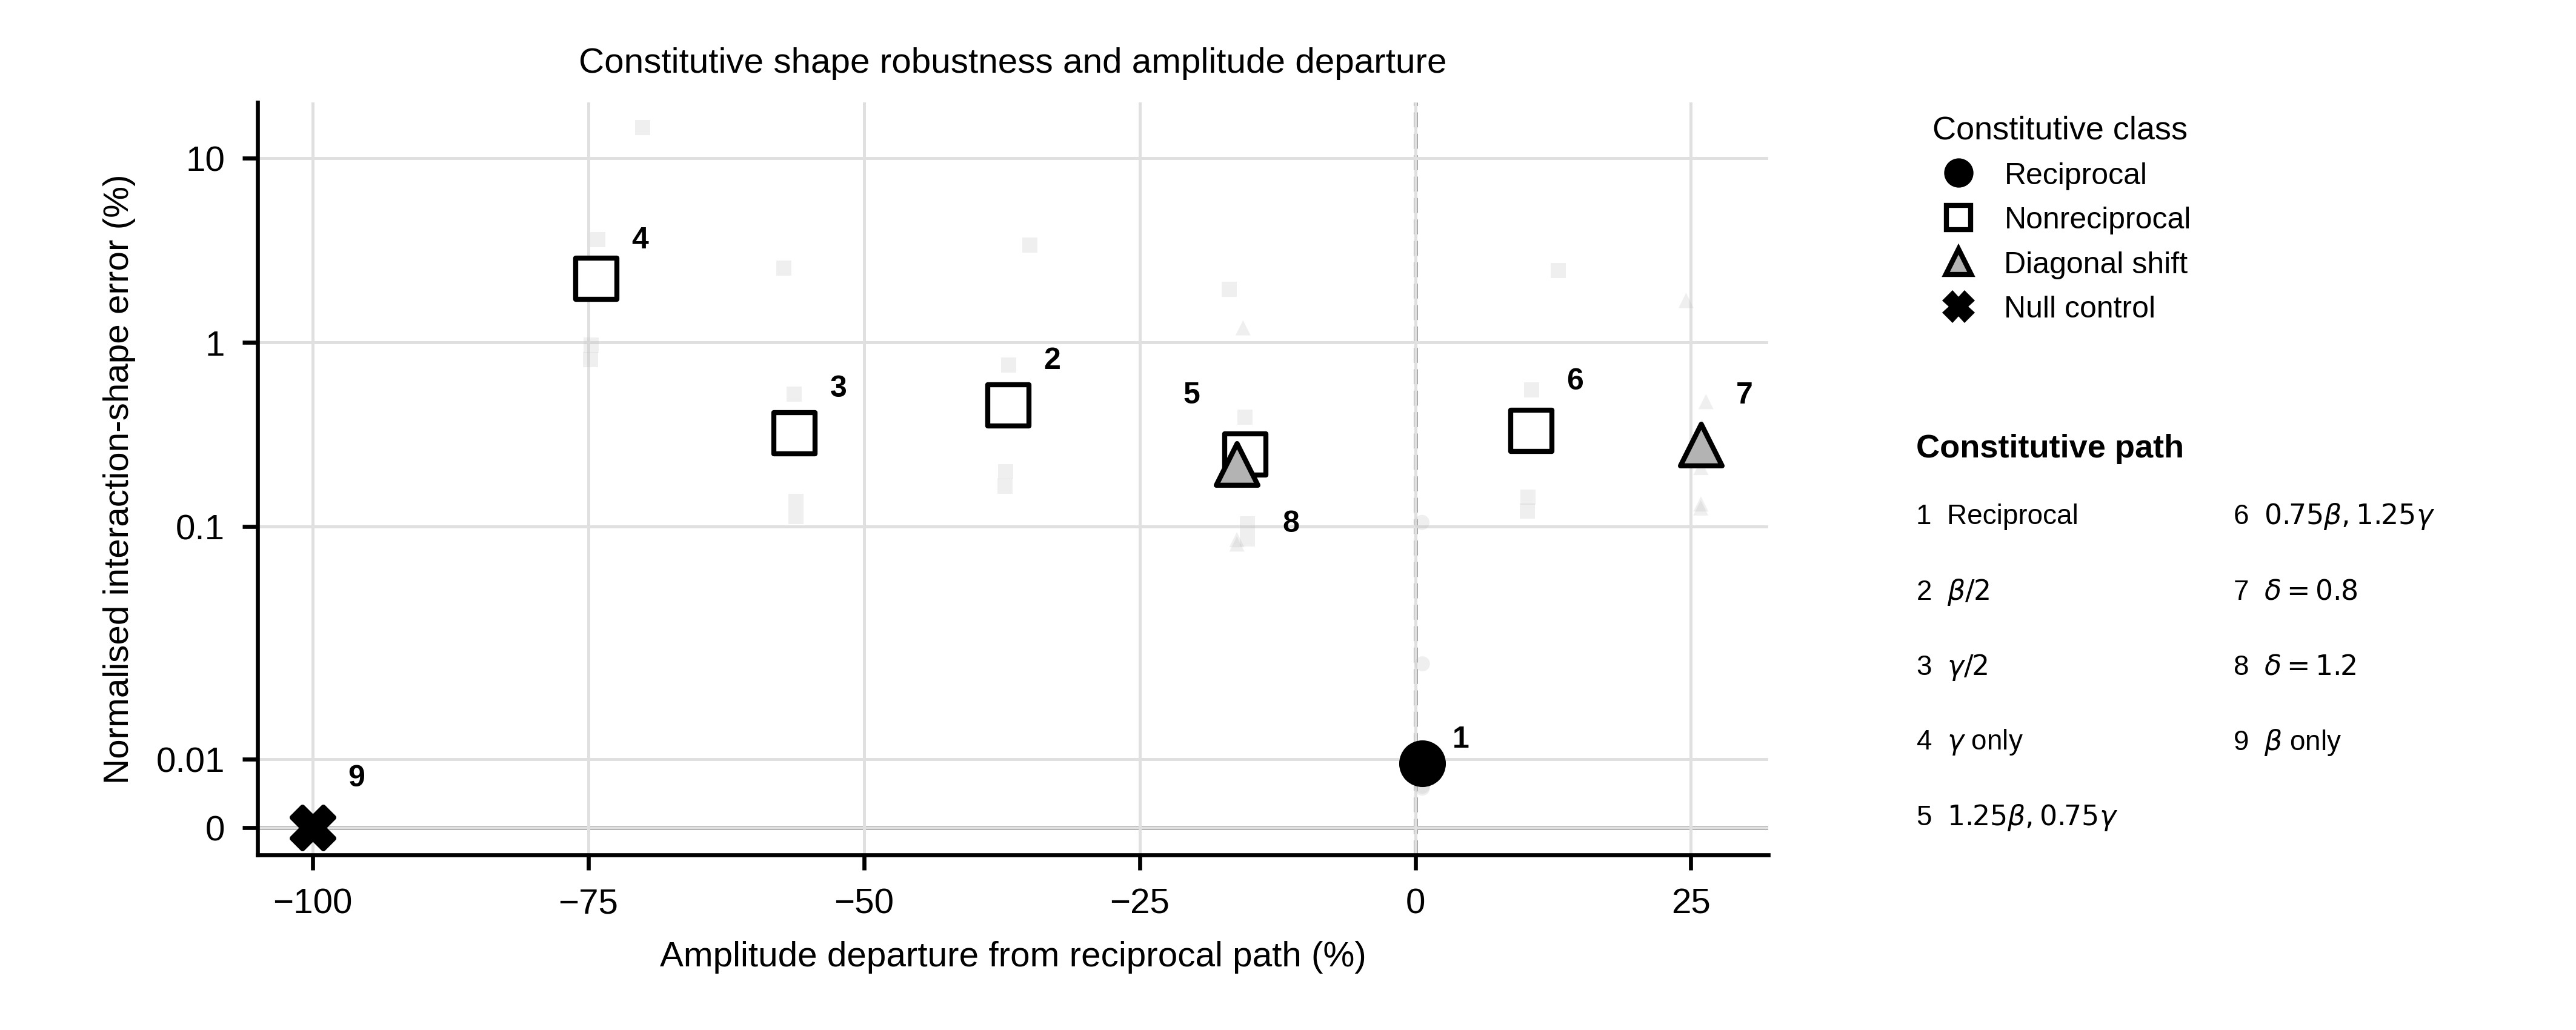

In [41]:
# Final Step 6 — Supplementary Figure S1
# Constitutive shape robustness and amplitude departure.
# Produces one publication-ready PNG and displays it in the output cell.

from IPython.display import Image, display
from matplotlib.lines import Line2D

plt.close("all")

required_globals = [
    "ANALYSIS_ROOT",
    "ROBUSTNESS",
    "ARTICLE_WIDTH_MM",
    "RASTER_DPI",
    "mm_to_inches",
    "clean_axis",
    "np",
    "pd",
    "plt",
]

missing_globals = [
    name for name in required_globals
    if name not in globals()
]

if missing_globals:
    raise RuntimeError(
        "Run the existing load and publication-style cells first. "
        f"Missing globals: {missing_globals}"
    )

FINAL_FIGURE_ROOT = ANALYSIS_ROOT / "figures_final"
FINAL_SOURCE_ROOT = FINAL_FIGURE_ROOT / "figure_sources"

FINAL_FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_SOURCE_ROOT.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Validate and prepare constitutive-robustness data
# ============================================================
required_columns = {
    "artery_id",
    "constitutive_path",
    "relative_amplitude_to_reciprocal",
    "normalised_shape_relative_l2",
}

missing_columns = sorted(
    required_columns.difference(ROBUSTNESS.columns)
)

if missing_columns:
    raise KeyError(
        "constitutive_robustness.csv is missing columns: "
        f"{missing_columns}"
    )

robustness = ROBUSTNESS.copy()

robustness["relative_amplitude_to_reciprocal"] = pd.to_numeric(
    robustness["relative_amplitude_to_reciprocal"],
    errors="coerce",
)

robustness["normalised_shape_relative_l2"] = pd.to_numeric(
    robustness["normalised_shape_relative_l2"],
    errors="coerce",
)

robustness["amplitude_departure_percent"] = (
    100.0
    * (
        robustness["relative_amplitude_to_reciprocal"]
        - 1.0
    )
)

robustness["shape_error_percent"] = (
    100.0
    * robustness["normalised_shape_relative_l2"]
)

valid_mask = (
    np.isfinite(
        robustness["amplitude_departure_percent"]
    )
    & np.isfinite(
        robustness["shape_error_percent"]
    )
    & (
        robustness["shape_error_percent"]
        >= 0.0
    )
)

robustness = (
    robustness.loc[valid_mask]
    .reset_index(drop=True)
)

if robustness.empty:
    raise ValueError(
        "No valid constitutive-robustness cases were found."
    )

# ============================================================
# 2. Constitutive-path definitions
# ============================================================
PATH_ORDER = [
    "reciprocal",
    "beta_low",
    "gamma_low",
    "gamma_only",
    "beta_high_gamma_low",
    "beta_low_gamma_high",
    "delta_low",
    "delta_high",
    "beta_only",
]

PATH_NUMBER = {
    path: index + 1
    for index, path in enumerate(PATH_ORDER)
}

PATH_LABELS = {
    "reciprocal": "Reciprocal",
    "beta_low": r"$\beta/2$",
    "gamma_low": r"$\gamma/2$",
    "gamma_only": r"$\gamma$ only",
    "beta_high_gamma_low":
        r"$1.25\beta,0.75\gamma$",
    "beta_low_gamma_high":
        r"$0.75\beta,1.25\gamma$",
    "delta_low": r"$\delta=0.8$",
    "delta_high": r"$\delta=1.2$",
    "beta_only": r"$\beta$ only",
}

PATH_CLASS = {
    "reciprocal": "Reciprocal",
    "beta_low": "Nonreciprocal",
    "gamma_low": "Nonreciprocal",
    "gamma_only": "Nonreciprocal",
    "beta_high_gamma_low": "Nonreciprocal",
    "beta_low_gamma_high": "Nonreciprocal",
    "delta_low": "Diagonal shift",
    "delta_high": "Diagonal shift",
    "beta_only": "Null control",
}

CLASS_MARKERS = {
    "Reciprocal": "o",
    "Nonreciprocal": "s",
    "Diagonal shift": "^",
    "Null control": "X",
}

CLASS_MEDIAN_FACES = {
    "Reciprocal": "black",
    "Nonreciprocal": "white",
    "Diagonal shift": "0.70",
    "Null control": "black",
}

available_paths = set(
    robustness["constitutive_path"].astype(str)
)

missing_paths = [
    path
    for path in PATH_ORDER
    if path not in available_paths
]

if missing_paths:
    raise ValueError(
        "The expected constitutive paths are incomplete. "
        f"Missing: {missing_paths}"
    )

robustness["path_class"] = (
    robustness["constitutive_path"]
    .map(PATH_CLASS)
)

if robustness["path_class"].isna().any():
    unknown_paths = sorted(
        robustness.loc[
            robustness["path_class"].isna(),
            "constitutive_path",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise ValueError(
        "Unclassified constitutive paths were found: "
        f"{unknown_paths}"
    )

# ============================================================
# 3. Path-level summaries
# ============================================================
summary_rows = []

for path in PATH_ORDER:
    subset = robustness[
        robustness["constitutive_path"] == path
    ]

    if subset.empty:
        raise ValueError(
            f"No cases were found for constitutive path {path!r}."
        )

    summary_rows.append(
        {
            "constitutive_path": path,
            "path_number": PATH_NUMBER[path],
            "path_label": PATH_LABELS[path],
            "path_class": PATH_CLASS[path],
            "case_count": int(len(subset)),
            "amplitude_min_percent": float(
                subset["amplitude_departure_percent"].min()
            ),
            "amplitude_median_percent": float(
                subset["amplitude_departure_percent"].median()
            ),
            "amplitude_max_percent": float(
                subset["amplitude_departure_percent"].max()
            ),
            "shape_min_percent": float(
                subset["shape_error_percent"].min()
            ),
            "shape_median_percent": float(
                subset["shape_error_percent"].median()
            ),
            "shape_max_percent": float(
                subset["shape_error_percent"].max()
            ),
        }
    )

path_summary = pd.DataFrame(summary_rows)

if path_summary["case_count"].nunique() != 1:
    raise ValueError(
        "The constitutive paths contain unequal numbers "
        "of arterial cases."
    )

# ============================================================
# 4. Export exact plotted source data
# ============================================================
case_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_S1_constitutive_robustness_final_cases.csv"
)

summary_source_path = (
    FINAL_SOURCE_ROOT
    / "figure_S1_constitutive_robustness_final_summary.csv"
)

robustness.to_csv(
    case_source_path,
    index=False,
)

path_summary.to_csv(
    summary_source_path,
    index=False,
)

# ============================================================
# 5. Controlled figure layout
# ============================================================
fig = plt.figure(
    figsize=(
        mm_to_inches(ARTICLE_WIDTH_MM),
        mm_to_inches(72.0),
    )
)

grid = fig.add_gridspec(
    1,
    2,
    width_ratios=[3.35, 1.35],
    left=0.10,
    right=0.98,
    bottom=0.17,
    top=0.90,
    wspace=0.14,
)

ax = fig.add_subplot(grid[0, 0])
key_ax = fig.add_subplot(grid[0, 1])

key_ax.axis("off")

# ============================================================
# 6. Individual artery-level constitutive cases
# ============================================================
for path in PATH_ORDER:
    subset = robustness[
        robustness["constitutive_path"] == path
    ]

    path_class = PATH_CLASS[path]

    ax.scatter(
        subset["amplitude_departure_percent"],
        subset["shape_error_percent"],
        s=9,
        marker=CLASS_MARKERS[path_class],
        facecolor="0.72",
        edgecolor="none",
        alpha=0.22,
        zorder=2,
    )

# ============================================================
# 7. Constitutive-path medians
# ============================================================
NUMBER_OFFSETS = {
    "reciprocal": (6, 2, "left", "bottom"),
    "beta_low": (7, 6, "left", "bottom"),
    "gamma_low": (7, 6, "left", "bottom"),
    "gamma_only": (7, 5, "left", "bottom"),
    "beta_high_gamma_low":
        (-9, 9, "right", "bottom"),
    "beta_low_gamma_high":
        (7, 7, "left", "bottom"),
    "delta_low": (7, 7, "left", "bottom"),
    "delta_high": (9, -9, "left", "top"),
    "beta_only": (7, 7, "left", "bottom"),
}

for row in path_summary.itertuples(index=False):
    ax.scatter(
        row.amplitude_median_percent,
        row.shape_median_percent,
        s=68,
        marker=CLASS_MARKERS[row.path_class],
        facecolor=CLASS_MEDIAN_FACES[row.path_class],
        edgecolor="black",
        linewidth=1.0,
        zorder=5,
    )

    dx, dy, horizontal_alignment, vertical_alignment = (
        NUMBER_OFFSETS[row.constitutive_path]
    )

    ax.annotate(
        str(row.path_number),
        xy=(
            row.amplitude_median_percent,
            row.shape_median_percent,
        ),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=horizontal_alignment,
        va=vertical_alignment,
        fontsize=6.0,
        fontweight="bold",
        zorder=6,
    )

# ============================================================
# 8. Quantitative axes
# ============================================================
ax.axvline(
    0.0,
    color="0.50",
    linestyle="--",
    linewidth=0.8,
    zorder=0,
)

ax.axhline(
    0.0,
    color="0.50",
    linewidth=0.8,
    zorder=0,
)

# Symmetric-logarithmic scaling preserves zero while resolving
# the sub-percent shape-error range.
ax.set_yscale(
    "symlog",
    linthresh=0.03,
    linscale=1.0,
    base=10,
)

ax.set_yticks(
    [0.0, 0.01, 0.1, 1.0, 10.0]
)

ax.set_yticklabels(
    ["0", "0.01", "0.1", "1", "10"]
)

x_minimum = float(
    robustness["amplitude_departure_percent"].min()
)

x_maximum = float(
    robustness["amplitude_departure_percent"].max()
)

y_maximum = float(
    robustness["shape_error_percent"].max()
)

ax.set_xlim(
    min(-105.0, x_minimum - 4.0),
    max(32.0, x_maximum + 4.0),
)

ax.set_ylim(
    -0.004,
    max(20.0, 1.20 * y_maximum),
)

ax.set_xticks(
    [-100, -75, -50, -25, 0, 25]
)

ax.set_xlabel(
    "Amplitude departure from reciprocal path (%)"
)

ax.set_ylabel(
    "Normalised interaction-shape error (%)"
)

ax.set_title(
    "Constitutive shape robustness and amplitude departure"
)

ax.grid(
    axis="both",
    color="0.88",
    linewidth=0.6,
    zorder=0,
)

clean_axis(
    ax,
    "both",
)

# ============================================================
# 9. Constitutive-class legend
# ============================================================
class_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=4.8,
        label="Reciprocal",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=4.8,
        label="Nonreciprocal",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="none",
        markerfacecolor="0.70",
        markeredgecolor="black",
        markersize=5.0,
        label="Diagonal shift",
    ),
    Line2D(
        [0],
        [0],
        marker="X",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=5.0,
        label="Null control",
    ),
]

key_ax.legend(
    handles=class_handles,
    title="Constitutive class",
    loc="upper left",
    bbox_to_anchor=(0.0, 1.0),
    frameon=False,
    borderaxespad=0.0,
    handletextpad=0.50,
    labelspacing=0.55,
    fontsize=6.0,
    title_fontsize=6.5,
)

# ============================================================
# 10. Compact two-column constitutive-path key
# ============================================================
key_ax.text(
    0.0,
    0.52,
    "Constitutive path",
    ha="left",
    va="bottom",
    fontsize=6.5,
    fontweight="bold",
)

left_column_paths = PATH_ORDER[:5]
right_column_paths = PATH_ORDER[5:]

key_y_positions = [
    0.45,
    0.35,
    0.25,
    0.15,
    0.05,
]

for y_position, path in zip(
    key_y_positions,
    left_column_paths,
):
    key_ax.text(
        0.0,
        y_position,
        f"{PATH_NUMBER[path]}  {PATH_LABELS[path]}",
        ha="left",
        va="center",
        fontsize=5.5,
    )

for y_position, path in zip(
    key_y_positions[:4],
    right_column_paths,
):
    key_ax.text(
        0.52,
        y_position,
        f"{PATH_NUMBER[path]}  {PATH_LABELS[path]}",
        ha="left",
        va="center",
        fontsize=5.5,
    )

# ============================================================
# 11. Render validation, save and display
# ============================================================
png_path = (
    FINAL_FIGURE_ROOT
    / "figure_S1_constitutive_robustness_final.png"
)

try:
    fig.canvas.draw()
except Exception:
    plt.close(fig)
    raise

fig.savefig(
    png_path,
    dpi=RASTER_DPI,
    facecolor="white",
    transparent=False,
)

plt.close(fig)

print(f"Final Figure S1 saved to: {png_path}")
print(f"Case-level source saved to: {case_source_path}")
print(f"Path summary saved to: {summary_source_path}")
print(
    "Caption definitions: small grey symbols denote individual "
    "arterial cases; large outlined symbols denote constitutive-path "
    "medians. Amplitude departure is measured relative to the reciprocal "
    "path. The vertical axis uses symmetric-logarithmic scaling with a "
    "linear region around zero."
)

display(
    Image(
        filename=str(png_path)
    )
)